In [2]:
# ============================================================
# MALL CUSTOMER SEGMENTATION
# UNSUPERVISED LEARNING - PR 1
# ============================================================
# Project:
#   Mall Customer Segmentation using
#   K-Means, Agglomerative Hierarchical Clustering and DBSCAN
#
# Dataset:
#   Kaggle - Mall Customer Segmentation Dataset
#
# Purpose:
#   Discover meaningful customer segments and translate
#   clustering results into business/marketing insights.
# ============================================================


# ============================================================
# 1. SYSTEM & GENERAL UTILITIES
# ============================================================

import os
import warnings
from pathlib import Path


# ============================================================
# 2. NUMERICAL COMPUTATION
# ============================================================

import numpy as np


# ============================================================
# 3. DATA MANIPULATION
# ============================================================

import pandas as pd


# ============================================================
# 4. DATA VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 5. KAGGLE DATASET DOWNLOAD
# ============================================================

import kagglehub


# ============================================================
# 6. DATA PREPROCESSING
# ============================================================

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)


# ============================================================
# 7. CLUSTERING ALGORITHMS
# ============================================================

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)


# ============================================================
# 8. CLUSTER VALIDATION METRICS
# ============================================================

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)


# ============================================================
# 9. DBSCAN PARAMETER ANALYSIS
# ============================================================

from sklearn.neighbors import NearestNeighbors


# ============================================================
# 10. HIERARCHICAL CLUSTERING VISUALIZATION
# ============================================================

from scipy.cluster.hierarchy import (
    dendrogram,
    linkage
)


# ============================================================
# 11. WARNING & DISPLAY SETTINGS
# ============================================================

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.2f}"
)


# ============================================================
# 12. VISUALIZATION STYLE
# ============================================================

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 100


# ============================================================
# 13. PROJECT CONFIGURATION
# ============================================================

RANDOM_STATE = 42

PROJECT_NAME = "Mall Customer Segmentation"

DATASET_NAME = "Mall Customer Segmentation Dataset"

KAGGLE_DATASET = (
    "vjchoudhary7/"
    "customer-segmentation-tutorial-in-python"
)


# ============================================================
# 14. SUCCESS MESSAGE
# ============================================================

print("=" * 70)
print("MASTER IMPORTS LOADED SUCCESSFULLY")
print("=" * 70)

print(f"Project       : {PROJECT_NAME}")
print(f"Dataset       : {DATASET_NAME}")
print(f"Random State  : {RANDOM_STATE}")

print("\nAll libraries required for this project are ready.")


MASTER IMPORTS LOADED SUCCESSFULLY
Project       : Mall Customer Segmentation
Dataset       : Mall Customer Segmentation Dataset
Random State  : 42

All libraries required for this project are ready.


MALL CUSTOMER SEGMENTATION USING UNSUPERVISED LEARNING

PROJECT OBJECTIVE
-----------------
The objective of this project is to identify meaningful customer segments
using unsupervised learning techniques based on customer age, annual income
and spending behaviour.

The project compares:

• K-Means Clustering
• Agglomerative Hierarchical Clustering
• DBSCAN

The resulting clusters will be evaluated using multiple internal clustering
metrics and subsequently interpreted from a customer-business perspective.

BUSINESS QUESTION

Can customers be grouped into meaningful segments based on their
demographic, financial and spending characteristics?

The discovered segments will later be profiled and translated into
potential customer insights and marketing strategies.

ANALYTICAL METHODOLOGY

The project follows a structured analytical workflow:

1. Dataset acquisition and initial inspection
2. Dataset structure and statistical overview
3. Data quality assessment
4. Feature preparation and se

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


1.2 DATASET STRUCTURE & STATISTICAL OVERVIEW

Number of observations : 200
Number of variables   : 5

Dataset Variables:
1. CustomerID
2. Gender
3. Age
4. Annual Income (k$)
5. Spending Score (1-100)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

First 5 Observations:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Last 5 Observations:


...


✓ No missing values were detected.
✓ No duplicate records were detected.
✓ Customer IDs are unique.
✓ No missing-value treatment is required.
✓ No duplicate-record treatment is required.
✓ The dataset is suitable for further analytical preparation.

1.4 DATA PREPARATION & ANALYTICAL FEATURE DEFINITION

Primary Clustering Features:
✓ Age
✓ Annual_Income
✓ Spending_Score

Prepared Analytical Dataset:


,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40



Prepared Dataset Shape: (200, 4)

Feature Selection Decision:


,Feature,Analytical_Role,Primary_Clustering,Reason
0,CustomerID,Identifier,Exclude,Unique identifier with no behavioural meaning.
1,Gender,Demographic,Exclude,Retained for descriptive customer profiling bu...
2,Age,Demographic,Include,Represents customer demographic variation.
3,Annual_Income,Financial,Include,Represents customer purchasing capacity.
4,Spending_Score,Behavioural,Include,Represents customer spending behaviour.


1.5 EXPLORATORY DATA ANALYSIS & DISTRIBUTION PATTERNS


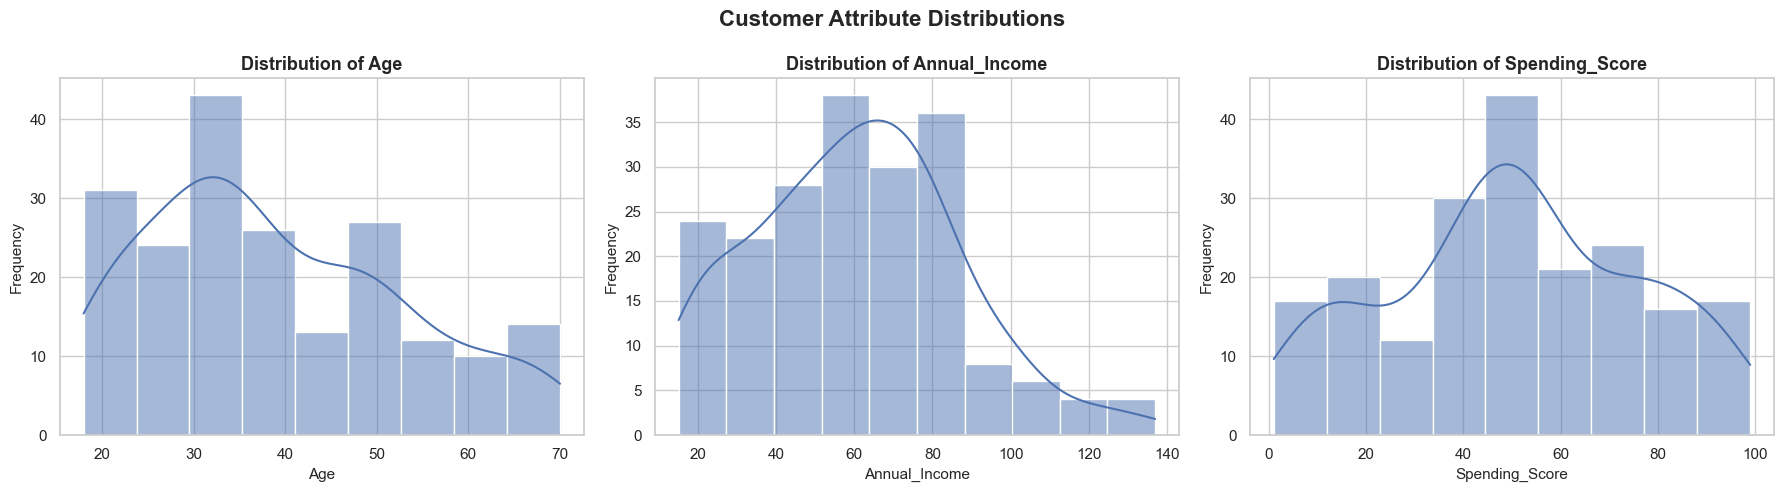

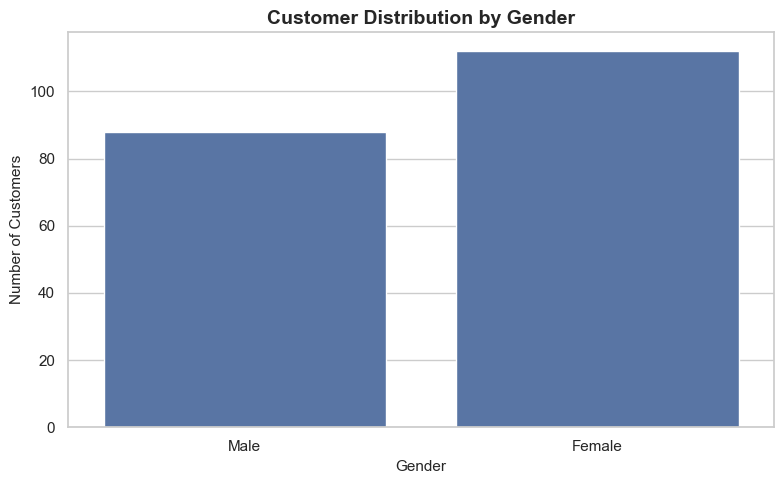


Generating pairwise relationship analysis...


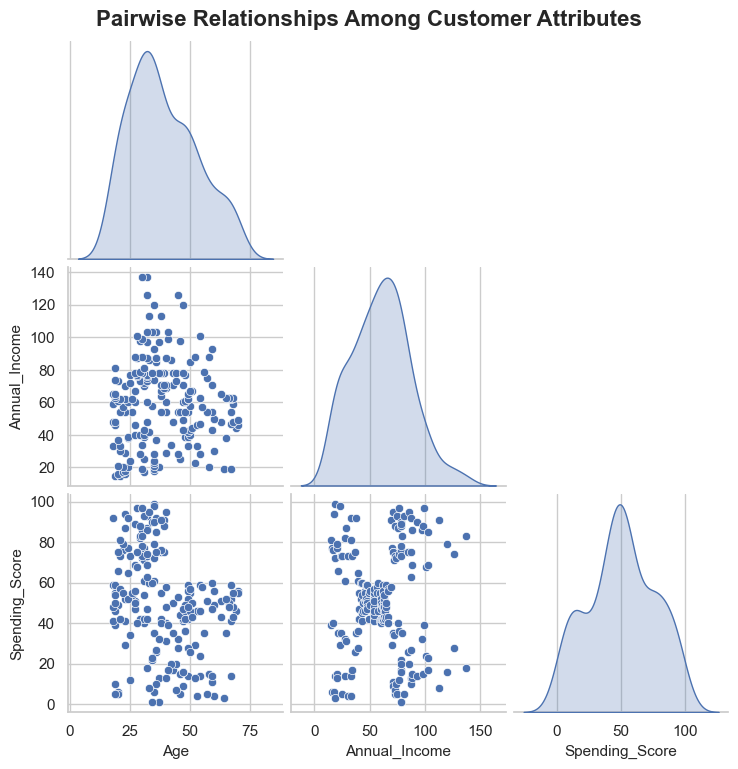

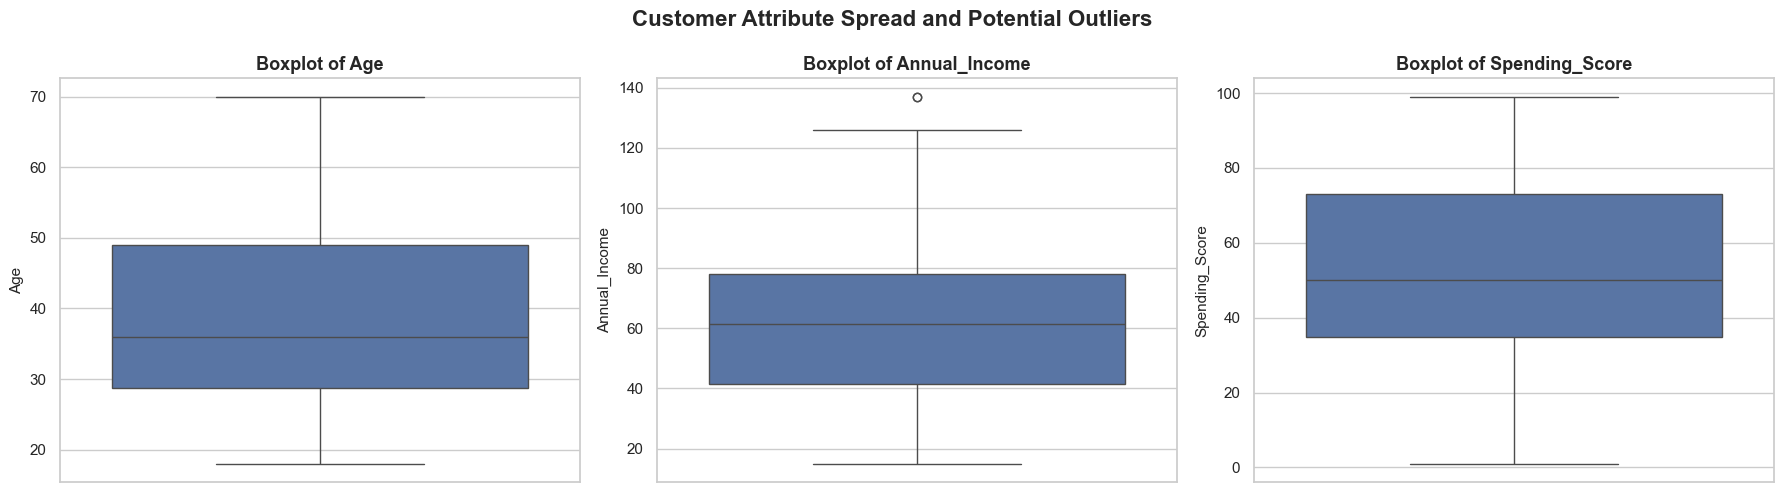


Descriptive EDA Summary:


,mean,median,std,min,max,skewness
Age,38.85,36.00,13.97,18.00,70.00,0.49
Annual_Income,60.56,61.50,26.26,15.00,137.00,0.32
Spending_Score,50.20,50.00,25.82,1.00,99.00,-0.05



Key EDA Observations:
• Age: Mean = 38.85, Median = 36.00, Skewness = 0.49
• Annual_Income: Mean = 60.56, Median = 61.50, Skewness = 0.32
• Spending_Score: Mean = 50.20, Median = 50.00, Skewness = -0.05

EDA-DRIVEN CUSTOMER BEHAVIOUR INTERPRETATION

1. AGE
   Customers cover a broad age range, providing meaningful demographic
   variation that can contribute to customer segmentation.

2. ANNUAL INCOME
   Annual Income varies across customers, indicating differences in
   purchasing capacity.

3. SPENDING SCORE
   Spending Score covers a broad range, indicating substantial variation
   in customer spending behaviour.

4. CUSTOMER HETEROGENEITY
   The variation across these attributes indicates that customers are not
   completely homogeneous with respect to the selected characteristics.

5. CLUSTERING IMPLICATION
   These differences provide a logical basis for investigating whether
   naturally occurring customer groups can be identified using
   unsupervised learning.

1.6 FEATURE RE

,Age,Annual_Income,Spending_Score
Age,1.00,-0.01,-0.33
Annual_Income,-0.01,1.00,0.01
Spending_Score,-0.33,0.01,1.00


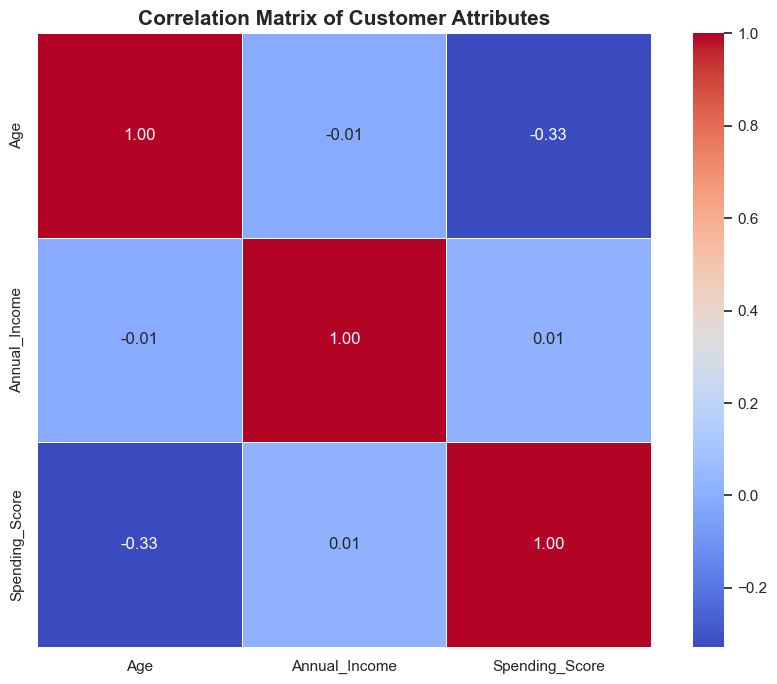


Strongest observed relationship: Age ↔ Spending_Score
Correlation coefficient: -0.327

Important Correlation Relationships:
• Age ↔ Spending Score          : -0.327
• Annual Income ↔ Spending Score : 0.010
• Age ↔ Annual Income           : -0.012

CORRELATION-BASED ANALYTICAL INTERPRETATION

• Age and Spending Score show the strongest linear association among
  the selected customer attributes, with a correlation of
  -0.327.

• The negative direction indicates that higher age tends to be associated
  with lower Spending Score in this sample.

• Annual Income and Spending Score show a correlation of
  0.010, indicating very little linear association.

• This suggests that purchasing capacity and spending behaviour capture
  different dimensions of customer characteristics.

• Age and Annual Income show a correlation of
  -0.012, indicating very little linear association.

• The relatively weak pairwise correlations indicate that the selected
  variables provide complementary informati

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,Age,28.75,49.00,20.25,-1.62,79.38,0,0.00
1,Annual_Income,41.50,78.00,36.50,-13.25,132.75,2,1.00
2,Spending_Score,34.75,73.00,38.25,-22.62,130.38,0,0.00



Outlier Treatment Decision:

Potential observations outside the IQR-based bounds are not automatically
removed.

In customer segmentation, unusual observations may represent genuine
customer behaviour and can potentially form meaningful segments.

Therefore:

✓ Statistical outlier detection is performed.
✓ Potential outliers are documented.
✓ No observations are removed solely because they are statistically unusual.
✓ Any future treatment would require evidence that an observation is
  erroneous or creates a clear modelling problem.

1.8 WHY UNSUPERVISED CLUSTERING?

The dataset does not contain predefined customer segment labels.

Therefore, there is no target variable representing the correct customer
segment for supervised classification.

The objective of this project is instead to discover naturally occurring
groups within the customer feature space.

This makes unsupervised clustering appropriate because the algorithms can
identify customer groups based on similarities and diffe

,Feature,Role,Clustering_Decision,Decision_Reason
0,CustomerID,Identifier,Exclude,Identifier without behavioural meaning.
1,Gender,Descriptive demographic,Exclude,Useful for descriptive profiling but not inclu...
2,Age,Demographic,Include,Captures customer demographic variation.
3,Annual_Income,Financial,Include,Captures purchasing capacity.
4,Spending_Score,Behavioural,Include,Captures customer spending behaviour.



FINAL CLUSTERING FEATURE SPACE

✓ Age
✓ Annual Income
✓ Spending Score

These three variables will form the primary feature space for clustering.

Gender will remain available for descriptive profiling after clusters
have been created.

CustomerID will remain excluded because it is an identifier rather than
a meaningful customer characteristic.

STEP 1 DECISION GATE

EVIDENCE
--------

✓ The official Kaggle Mall Customer Segmentation dataset was successfully
  loaded.

✓ The dataset contains customer demographic, financial and behavioural
  information.

✓ No missing values were detected.

✓ No duplicate records were detected.

✓ Customer IDs are unique.

✓ CustomerID is an identifier and should not influence clustering.

✓ Gender is useful for descriptive profiling but is not part of the
  primary numerical clustering feature space.

✓ Age, Annual Income and Spending Score show meaningful variation.

✓ The selected variables represent different dimensions of customer
  characteristic

In [5]:
# ================================================================
# MALL CUSTOMER SEGMENTATION
# UNSUPERVISED LEARNING — PR 1
# ================================================================


# ============================================================
# STEP 1 : DATA LOADING & EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# Analytical Objective:
# Understand, validate, prepare and explore the official
# Mall Customer Segmentation dataset before clustering.
#
# Analytical Flow:
#
# Dataset Acquisition
#        ↓
# Dataset Structure & Inspection
#        ↓
# Data Quality Assessment
#        ↓
# Data Preparation & Feature Definition
#        ↓
# Exploratory Data Analysis
#        ↓
# Feature Relationship Analysis
#        ↓
# Outlier Assessment
#        ↓
# Unsupervised Learning Justification
#        ↓
# Feature Selection Decision
#        ↓
# Clustering Preparation
#
# Dataset Source:
# Kaggle
# vjchoudhary7/customer-segmentation-tutorial-in-python


# ============================================================
# PROJECT OBJECTIVE
# ============================================================

print("=" * 75)
print("MALL CUSTOMER SEGMENTATION USING UNSUPERVISED LEARNING")
print("=" * 75)

print("""
PROJECT OBJECTIVE
-----------------
The objective of this project is to identify meaningful customer segments
using unsupervised learning techniques based on customer age, annual income
and spending behaviour.

The project compares:

• K-Means Clustering
• Agglomerative Hierarchical Clustering
• DBSCAN

The resulting clusters will be evaluated using multiple internal clustering
metrics and subsequently interpreted from a customer-business perspective.
""")


# ============================================================
# BUSINESS QUESTION
# ============================================================

print("=" * 75)
print("BUSINESS QUESTION")
print("=" * 75)

print("""
Can customers be grouped into meaningful segments based on their
demographic, financial and spending characteristics?

The discovered segments will later be profiled and translated into
potential customer insights and marketing strategies.
""")


# ============================================================
# ANALYTICAL METHODOLOGY
# ============================================================

print("=" * 75)
print("ANALYTICAL METHODOLOGY")
print("=" * 75)

print("""
The project follows a structured analytical workflow:

1. Dataset acquisition and initial inspection
2. Dataset structure and statistical overview
3. Data quality assessment
4. Feature preparation and selection
5. Exploratory data analysis
6. Feature relationship and correlation analysis
7. Outlier assessment
8. Unsupervised learning justification
9. Feature standardization
10. K-Means clustering and cluster-number analysis
11. Agglomerative hierarchical clustering
12. DBSCAN density-based clustering
13. Multi-metric cluster evaluation
14. Algorithm comparison
15. Customer segment profiling
16. Business interpretation and recommendations
""")


# ============================================================
# 1.1 DATASET ACQUISITION & INITIAL INSPECTION
# ============================================================

print("=" * 75)
print("1.1 DATASET ACQUISITION & INITIAL INSPECTION")
print("=" * 75)


# Download the official dataset from Kaggle.
kaggle_path = kagglehub.dataset_download(
    "vjchoudhary7/customer-segmentation-tutorial-in-python"
)

print("\nOfficial Kaggle dataset downloaded successfully.")
print(f"Dataset location: {kaggle_path}")


# Locate the official CSV file inside the downloaded dataset.
csv_files = list(
    Path(kaggle_path).rglob("Mall_Customers.csv")
)


# Stop execution if the expected dataset file is not found.
if not csv_files:
    raise FileNotFoundError(
        "Mall_Customers.csv was not found in the downloaded Kaggle dataset."
    )


# Select the dataset file.
csv_path = csv_files[0]


# Load the dataset into a Pandas DataFrame.
df = pd.read_csv(csv_path)


print(f"\nDataset file     : {csv_path.name}")
print("Dataset status   : Successfully loaded")
print(f"Dataset shape    : {df.shape}")


print("\nFirst 5 Observations:")
display(df.head())


# ============================================================
# 1.2 DATASET STRUCTURE & STATISTICAL OVERVIEW
# ============================================================

print("=" * 75)
print("1.2 DATASET STRUCTURE & STATISTICAL OVERVIEW")
print("=" * 75)


# ------------------------------------------------------------
# Dataset Dimensions
# ------------------------------------------------------------

print(f"\nNumber of observations : {df.shape[0]}")
print(f"Number of variables   : {df.shape[1]}")


# ------------------------------------------------------------
# Dataset Variables
# ------------------------------------------------------------

print("\nDataset Variables:")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")


# ------------------------------------------------------------
# Dataset Information
# ------------------------------------------------------------

print("\nDataset Information:")

df.info()


# ------------------------------------------------------------
# Sample Observations
# ------------------------------------------------------------

print("\nFirst 5 Observations:")

display(df.head())


print("\nLast 5 Observations:")

display(df.tail())


# ------------------------------------------------------------
# Statistical Overview
# ------------------------------------------------------------

print("\nStatistical Summary:")

statistical_summary = df.describe(
    include="all"
).T

display(statistical_summary)


# ============================================================
# 1.3 DATA QUALITY ASSESSMENT
# ============================================================

print("=" * 75)
print("1.3 DATA QUALITY ASSESSMENT")
print("=" * 75)


# ------------------------------------------------------------
# Missing Value Assessment
# ------------------------------------------------------------

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing_Values": missing_values,
    "Missing_Percentage": (
        missing_values / len(df) * 100
    )
})

print("\nMissing Value Assessment:")

display(
    missing_summary
)


# ------------------------------------------------------------
# Duplicate Record Assessment
# ------------------------------------------------------------

duplicate_count = df.duplicated().sum()

print(
    f"Number of duplicate records : "
    f"{duplicate_count}"
)


# ------------------------------------------------------------
# Customer ID Uniqueness
# ------------------------------------------------------------

customer_id_duplicates = (
    df["CustomerID"].duplicated().sum()
)

print(
    f"Duplicate Customer IDs      : "
    f"{customer_id_duplicates}"
)


# ------------------------------------------------------------
# Categorical Variable Assessment
# ------------------------------------------------------------

print("\nUnique Gender Categories:")

print(
    df["Gender"].unique()
)


print("\nGender Distribution:")

gender_distribution = (
    df["Gender"]
    .value_counts()
    .rename_axis("Gender")
    .reset_index(name="Customer_Count")
)

display(
    gender_distribution
)


# ------------------------------------------------------------
# Numerical Range Assessment
# ------------------------------------------------------------

print("\nNumerical Feature Ranges:")

range_summary = pd.DataFrame({

    "Minimum": [
        df["Age"].min(),
        df["Annual Income (k$)"].min(),
        df["Spending Score (1-100)"].min()
    ],

    "Maximum": [
        df["Age"].max(),
        df["Annual Income (k$)"].max(),
        df["Spending Score (1-100)"].max()
    ]

}, index=[

    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"

])

display(
    range_summary
)


# ------------------------------------------------------------
# Overall Data Quality Decision
# ------------------------------------------------------------

quality_checks = pd.DataFrame({

    "Quality_Check": [
        "Missing Values",
        "Duplicate Records",
        "Duplicate Customer IDs"
    ],

    "Issue_Count": [
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        int(df["CustomerID"].duplicated().sum())
    ]

})

print("\nData Quality Decision:")

display(
    quality_checks
)


total_quality_issues = (
    quality_checks["Issue_Count"].sum()
)


if total_quality_issues == 0:

    print("""
✓ No missing values were detected.
✓ No duplicate records were detected.
✓ Customer IDs are unique.
✓ No missing-value treatment is required.
✓ No duplicate-record treatment is required.
✓ The dataset is suitable for further analytical preparation.
""")

else:

    print("""
⚠ Data-quality issues were detected.
Further treatment is required before clustering.
""")


# ============================================================
# 1.4 DATA PREPARATION & ANALYTICAL FEATURE DEFINITION
# ============================================================

print("=" * 75)
print("1.4 DATA PREPARATION & ANALYTICAL FEATURE DEFINITION")
print("=" * 75)


# ------------------------------------------------------------
# Preserve Original Dataset
# ------------------------------------------------------------

# Work on a copy so that the original imported dataset
# remains unchanged.
df_clean = df.copy()


# ------------------------------------------------------------
# Standardize Column Names
# ------------------------------------------------------------

# Simplify column names for consistent analytical processing.
df_clean.rename(
    columns={
        "Annual Income (k$)": "Annual_Income",
        "Spending Score (1-100)": "Spending_Score"
    },
    inplace=True
)


# ------------------------------------------------------------
# Remove Identifier from Clustering Space
# ------------------------------------------------------------

# CustomerID is an identifier and does not represent
# customer behaviour.
#
# Including it in clustering could introduce meaningless
# numerical distance between customers.
df_clean.drop(
    columns=["CustomerID"],
    inplace=True
)


# ------------------------------------------------------------
# Define Primary Clustering Features
# ------------------------------------------------------------

clustering_features = [
    "Age",
    "Annual_Income",
    "Spending_Score"
]


print("\nPrimary Clustering Features:")

for feature in clustering_features:
    print(f"✓ {feature}")


# ------------------------------------------------------------
# Prepared Analytical Dataset
# ------------------------------------------------------------

print("\nPrepared Analytical Dataset:")

display(
    df_clean.head()
)


print(
    f"\nPrepared Dataset Shape: "
    f"{df_clean.shape}"
)


# ------------------------------------------------------------
# Feature Selection Decision
# ------------------------------------------------------------

feature_decision = pd.DataFrame({

    "Feature": [
        "CustomerID",
        "Gender",
        "Age",
        "Annual_Income",
        "Spending_Score"
    ],

    "Analytical_Role": [
        "Identifier",
        "Demographic",
        "Demographic",
        "Financial",
        "Behavioural"
    ],

    "Primary_Clustering": [
        "Exclude",
        "Exclude",
        "Include",
        "Include",
        "Include"
    ],

    "Reason": [

        "Unique identifier with no behavioural meaning.",

        "Retained for descriptive customer profiling but excluded "
        "from the primary numerical clustering space.",

        "Represents customer demographic variation.",

        "Represents customer purchasing capacity.",

        "Represents customer spending behaviour."
    ]
})


print("\nFeature Selection Decision:")

display(
    feature_decision
)


# ============================================================
# 1.5 EXPLORATORY DATA ANALYSIS & DISTRIBUTION PATTERNS
# ============================================================

print("=" * 75)
print("1.5 EXPLORATORY DATA ANALYSIS & DISTRIBUTION PATTERNS")
print("=" * 75)


# Define numerical features used for EDA.
eda_features = [
    "Age",
    "Annual_Income",
    "Spending_Score"
]


# ------------------------------------------------------------
# Numerical Feature Distribution Analysis
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)


for ax, feature in zip(
    axes,
    eda_features
):

    sns.histplot(
        data=df_clean,
        x=feature,
        kde=True,
        ax=ax
    )

    ax.set_title(
        f"Distribution of {feature}",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")


plt.suptitle(
    "Customer Attribute Distributions",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Gender Distribution Analysis
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

sns.countplot(
    data=df,
    x="Gender"
)

plt.title(
    "Customer Distribution by Gender",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Pairwise Customer Attribute Analysis
# ------------------------------------------------------------

print(
    "\nGenerating pairwise relationship analysis..."
)

pairplot = sns.pairplot(
    df_clean[clustering_features],
    diag_kind="kde",
    corner=True
)

pairplot.fig.suptitle(
    "Pairwise Relationships Among Customer Attributes",
    y=1.02,
    fontsize=16,
    fontweight="bold"
)

plt.show()


# ------------------------------------------------------------
# Distribution Spread & Potential Outlier Analysis
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)


for ax, feature in zip(
    axes,
    eda_features
):

    sns.boxplot(
        y=df_clean[feature],
        ax=ax
    )

    ax.set_title(
        f"Boxplot of {feature}",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_ylabel(feature)


plt.suptitle(
    "Customer Attribute Spread and Potential Outliers",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Descriptive Statistical Analysis
# ------------------------------------------------------------

eda_summary = (
    df_clean[eda_features]
    .agg(
        ["mean", "median", "std", "min", "max"]
    )
    .T
)


eda_summary["skewness"] = (
    df_clean[eda_features].skew()
)


print("\nDescriptive EDA Summary:")

display(
    eda_summary.round(2)
)


# ------------------------------------------------------------
# Numerical EDA Observations
# ------------------------------------------------------------

print("\nKey EDA Observations:")


for feature in eda_features:

    mean_value = (
        df_clean[feature].mean()
    )

    median_value = (
        df_clean[feature].median()
    )

    skew_value = (
        df_clean[feature].skew()
    )

    print(
        f"• {feature}: "
        f"Mean = {mean_value:.2f}, "
        f"Median = {median_value:.2f}, "
        f"Skewness = {skew_value:.2f}"
    )


# ------------------------------------------------------------
# EDA-Driven Customer Behaviour Interpretation
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("EDA-DRIVEN CUSTOMER BEHAVIOUR INTERPRETATION")
print("=" * 75)


print("""
1. AGE
   Customers cover a broad age range, providing meaningful demographic
   variation that can contribute to customer segmentation.

2. ANNUAL INCOME
   Annual Income varies across customers, indicating differences in
   purchasing capacity.

3. SPENDING SCORE
   Spending Score covers a broad range, indicating substantial variation
   in customer spending behaviour.

4. CUSTOMER HETEROGENEITY
   The variation across these attributes indicates that customers are not
   completely homogeneous with respect to the selected characteristics.

5. CLUSTERING IMPLICATION
   These differences provide a logical basis for investigating whether
   naturally occurring customer groups can be identified using
   unsupervised learning.
""")


# ============================================================
# 1.6 FEATURE RELATIONSHIP & CORRELATION ANALYSIS
# ============================================================

print("=" * 75)
print("1.6 FEATURE RELATIONSHIP & CORRELATION ANALYSIS")
print("=" * 75)


# ------------------------------------------------------------
# Correlation Matrix
# ------------------------------------------------------------

correlation_matrix = (
    df_clean[eda_features]
    .corr()
)


print("\nCorrelation Matrix:")

display(
    correlation_matrix.round(3)
)


# ------------------------------------------------------------
# Correlation Heatmap
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 7)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Matrix of Customer Attributes",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Identify Strongest Feature Relationship
# ------------------------------------------------------------

correlation_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(
                correlation_matrix.shape
            ),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)


if not correlation_pairs.empty:

    strongest_pair = (
        correlation_pairs.index[0]
    )

    strongest_value = (
        correlation_pairs.iloc[0]
    )

    print(
        f"\nStrongest observed relationship: "
        f"{strongest_pair[0]} ↔ {strongest_pair[1]}"
    )

    print(
        f"Correlation coefficient: "
        f"{strongest_value:.3f}"
    )


# ------------------------------------------------------------
# Important Correlation Relationships
# ------------------------------------------------------------

age_spending_corr = correlation_matrix.loc[
    "Age",
    "Spending_Score"
]

income_spending_corr = correlation_matrix.loc[
    "Annual_Income",
    "Spending_Score"
]

age_income_corr = correlation_matrix.loc[
    "Age",
    "Annual_Income"
]


print("\nImportant Correlation Relationships:")

print(
    f"• Age ↔ Spending Score          : "
    f"{age_spending_corr:.3f}"
)

print(
    f"• Annual Income ↔ Spending Score : "
    f"{income_spending_corr:.3f}"
)

print(
    f"• Age ↔ Annual Income           : "
    f"{age_income_corr:.3f}"
)


# ------------------------------------------------------------
# Correlation-Based Analytical Interpretation
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CORRELATION-BASED ANALYTICAL INTERPRETATION")
print("=" * 75)


print(f"""
• Age and Spending Score show the strongest linear association among
  the selected customer attributes, with a correlation of
  {age_spending_corr:.3f}.

• The negative direction indicates that higher age tends to be associated
  with lower Spending Score in this sample.

• Annual Income and Spending Score show a correlation of
  {income_spending_corr:.3f}, indicating very little linear association.

• This suggests that purchasing capacity and spending behaviour capture
  different dimensions of customer characteristics.

• Age and Annual Income show a correlation of
  {age_income_corr:.3f}, indicating very little linear association.

• The relatively weak pairwise correlations indicate that the selected
  variables provide complementary information about customers.

• Therefore, considering Age, Annual Income and Spending Score jointly
  can provide a more informative representation of customer profiles.

NOTE:
Correlation measures linear association. It does not establish causation
and does not by itself determine whether distinct clusters exist.
""")


# ============================================================
# 1.7 IQR-BASED OUTLIER ASSESSMENT
# ============================================================

print("=" * 75)
print("1.7 IQR-BASED OUTLIER ASSESSMENT")
print("=" * 75)


# IQR-based analysis is used to identify observations that fall
# outside the conventional statistical bounds.
#
# Important:
# Potential outliers are not automatically removed because unusual
# customers may represent genuine customer behaviour.


outlier_summary = []


for feature in eda_features:

    Q1 = df_clean[feature].quantile(0.25)

    Q3 = df_clean[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR

    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (
            df_clean[feature] < lower_bound
        )
        |
        (
            df_clean[feature] > upper_bound
        )
    ).sum()

    outlier_percentage = (
        outlier_count
        / len(df_clean)
        * 100
    )

    outlier_summary.append([

        feature,
        Q1,
        Q3,
        IQR,
        lower_bound,
        upper_bound,
        outlier_count,
        outlier_percentage

    ])


outlier_summary = pd.DataFrame(

    outlier_summary,

    columns=[

        "Feature",
        "Q1",
        "Q3",
        "IQR",
        "Lower_Bound",
        "Upper_Bound",
        "Outlier_Count",
        "Outlier_Percentage"

    ]
)


print("\nIQR-Based Outlier Summary:")

display(
    outlier_summary.round(2)
)


# ------------------------------------------------------------
# Outlier Treatment Decision
# ------------------------------------------------------------

print("\nOutlier Treatment Decision:")

print("""
Potential observations outside the IQR-based bounds are not automatically
removed.

In customer segmentation, unusual observations may represent genuine
customer behaviour and can potentially form meaningful segments.

Therefore:

✓ Statistical outlier detection is performed.
✓ Potential outliers are documented.
✓ No observations are removed solely because they are statistically unusual.
✓ Any future treatment would require evidence that an observation is
  erroneous or creates a clear modelling problem.
""")


# ============================================================
# 1.8 WHY UNSUPERVISED CLUSTERING?
# ============================================================

print("=" * 75)
print("1.8 WHY UNSUPERVISED CLUSTERING?")
print("=" * 75)


print("""
The dataset does not contain predefined customer segment labels.

Therefore, there is no target variable representing the correct customer
segment for supervised classification.

The objective of this project is instead to discover naturally occurring
groups within the customer feature space.

This makes unsupervised clustering appropriate because the algorithms can
identify customer groups based on similarities and differences in:

• Age
• Annual Income
• Spending Score

Three different clustering approaches will be investigated:

1. K-Means
   → Centroid-based clustering

2. Agglomerative Hierarchical Clustering
   → Hierarchical similarity-based clustering

3. DBSCAN
   → Density-based clustering

Using multiple algorithms allows the customer structure to be examined
from different clustering perspectives rather than relying on a single
method.
""")


# ============================================================
# 1.9 FEATURE SELECTION DECISION
# ============================================================

print("=" * 75)
print("1.9 FEATURE SELECTION DECISION")
print("=" * 75)


feature_selection_summary = pd.DataFrame({

    "Feature": [
        "CustomerID",
        "Gender",
        "Age",
        "Annual_Income",
        "Spending_Score"
    ],

    "Role": [
        "Identifier",
        "Descriptive demographic",
        "Demographic",
        "Financial",
        "Behavioural"
    ],

    "Clustering_Decision": [
        "Exclude",
        "Exclude",
        "Include",
        "Include",
        "Include"
    ],

    "Decision_Reason": [

        "Identifier without behavioural meaning.",

        "Useful for descriptive profiling but not included in the primary "
        "numerical clustering space.",

        "Captures customer demographic variation.",

        "Captures purchasing capacity.",

        "Captures customer spending behaviour."
    ]

})


display(
    feature_selection_summary
)


print("""
FINAL CLUSTERING FEATURE SPACE

✓ Age
✓ Annual Income
✓ Spending Score

These three variables will form the primary feature space for clustering.

Gender will remain available for descriptive profiling after clusters
have been created.

CustomerID will remain excluded because it is an identifier rather than
a meaningful customer characteristic.
""")


# ============================================================
# STEP 1 DECISION GATE
# ============================================================

print("=" * 75)
print("STEP 1 DECISION GATE")
print("=" * 75)


print("""
EVIDENCE
--------

✓ The official Kaggle Mall Customer Segmentation dataset was successfully
  loaded.

✓ The dataset contains customer demographic, financial and behavioural
  information.

✓ No missing values were detected.

✓ No duplicate records were detected.

✓ Customer IDs are unique.

✓ CustomerID is an identifier and should not influence clustering.

✓ Gender is useful for descriptive profiling but is not part of the
  primary numerical clustering feature space.

✓ Age, Annual Income and Spending Score show meaningful variation.

✓ The selected variables represent different dimensions of customer
  characteristics.

✓ No predefined customer segment label is available.


ANALYTICAL DECISION
-------------------

Age, Annual Income and Spending Score will form the primary clustering
feature space.


NEXT ANALYTICAL ACTION
----------------------

The selected features have different numerical ranges.

Because K-Means, Agglomerative Hierarchical Clustering and DBSCAN depend
on distance or neighbourhood relationships, the selected variables must
be standardized before clustering.

Therefore, the next step is:

STEP 2 → FEATURE SELECTION & STANDARDIZATION
""")


# ============================================================
# STEP 1 ANALYTICAL CONCLUSION
# ============================================================

print("=" * 75)
print("STEP 1 ANALYTICAL CONCLUSION")
print("=" * 75)


print(f"""
DATA UNDERSTANDING
------------------

✓ Official Kaggle dataset successfully loaded.
✓ {df.shape[0]} customer observations are available.
✓ {df.shape[1]} original variables are available.


DATA QUALITY
------------

✓ No missing values were detected.
✓ No duplicate records were detected.
✓ Customer IDs are unique.
✓ No data-quality treatment is required at this stage.


DATA PREPARATION
----------------

✓ CustomerID was removed from the clustering feature space.
✓ Gender is retained for descriptive profiling.
✓ Gender is excluded from the primary numerical clustering space.
✓ Analytical feature names were standardized.


EDA FINDINGS
------------

✓ Customers show meaningful variation in Age.
✓ Annual Income varies across customers.
✓ Spending Score shows substantial variation.
✓ The selected attributes indicate customer heterogeneity.


CORRELATION FINDINGS
--------------------

✓ Age and Spending Score show the strongest linear relationship.
✓ Annual Income and Spending Score show very little linear association.
✓ Age and Annual Income also show very little linear association.
✓ The selected variables therefore provide complementary information.


OUTLIER ASSESSMENT
------------------

✓ IQR-based outlier analysis was performed.
✓ Potential unusual observations were documented.
✓ No observations were automatically removed because unusual customers
  may represent genuine customer behaviour.


CLUSTERING DECISION
-------------------

✓ Age
✓ Annual Income
✓ Spending Score

These three features will form the primary clustering feature space.


NEXT ANALYTICAL STEP
--------------------

The selected features will be standardized before applying K-Means,
Agglomerative Hierarchical Clustering and DBSCAN because these algorithms
depend on distances or neighbourhood relationships.
""")


# ============================================================
# STEP 1 COMPLETED
# ============================================================

print("=" * 75)
print("STEP 1 COMPLETED : EDA → FEATURE SELECTION DECISION")
print("=" * 75)

print("""
Dataset Understanding ✓
Data Quality Assessment ✓
Feature Preparation ✓
EDA ✓
Correlation Analysis ✓
Outlier Assessment ✓
Unsupervised Learning Justification ✓
Feature Selection ✓
Decision Gate ✓

READY FOR STEP 2:
FEATURE SELECTION & STANDARDIZATION
""")

2.1 CLUSTERING FEATURE SPACE DEFINITION

Final Clustering Features:
1. Age
2. Annual_Income
3. Spending_Score

Raw Clustering Feature Matrix:


,Age,Annual_Income,Spending_Score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40



Number of observations       : 200
Number of clustering features: 3

Feature Data Types:


,Data_Type
Age,int64
Annual_Income,int64
Spending_Score,int64



Missing Values in Clustering Matrix:


...

2.4 SCALED FEATURE VALIDATION

Scaled Feature Validation:


,Feature,Mean_After_Scaling,Population_Std_After_Scaling,Minimum_After_Scaling,Maximum_After_Scaling
0,Age,-0.00,1.00,-1.50,2.24
1,Annual_Income,-0.00,1.00,-1.74,2.92
2,Spending_Score,-0.00,1.00,-1.91,1.89



Scaling Validation Decision:

✓ Mean of each standardized feature is approximately 0.
✓ Population standard deviation of each standardized feature is 1.
✓ Standardization was successfully applied.
✓ The feature space is ready for clustering.

2.5 RAW VS STANDARDIZED FEATURE COMPARISON


,Feature,Raw_Mean,Raw_Std,Scaled_Mean,Scaled_Population_Std
0,Age,38.85,13.97,-0.00,1.00
1,Annual_Income,60.56,26.26,-0.00,1.00
2,Spending_Score,50.20,25.82,-0.00,1.00



INTERPRETATION:

Before standardization, the customer attributes operate on different
numerical scales.

After standardization:

✓ Feature means are approximately 0.
✓ Population standard deviations are approximately 1.
✓ No selected feature is given dominance simply because of its original
  measurement scale.

Therefore, the transformed matrix is appropriate for distance-based
clustering.

2.6 VISUAL VALIDATION OF STANDARDIZATION


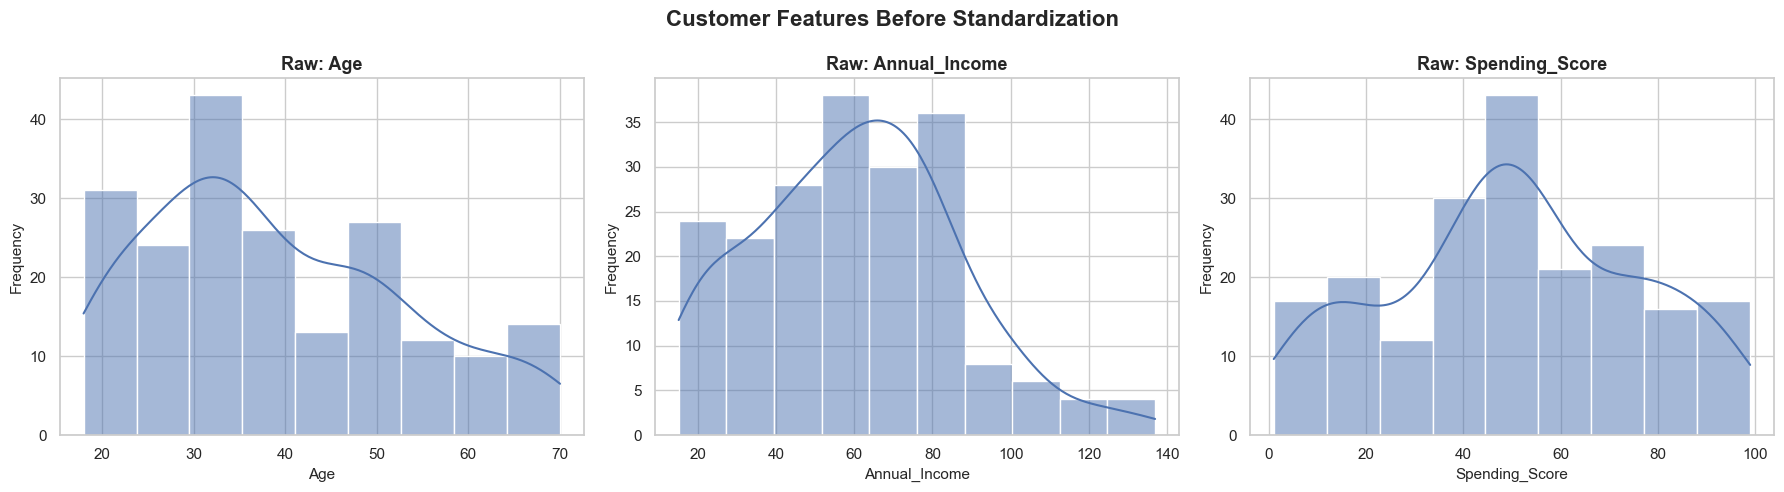

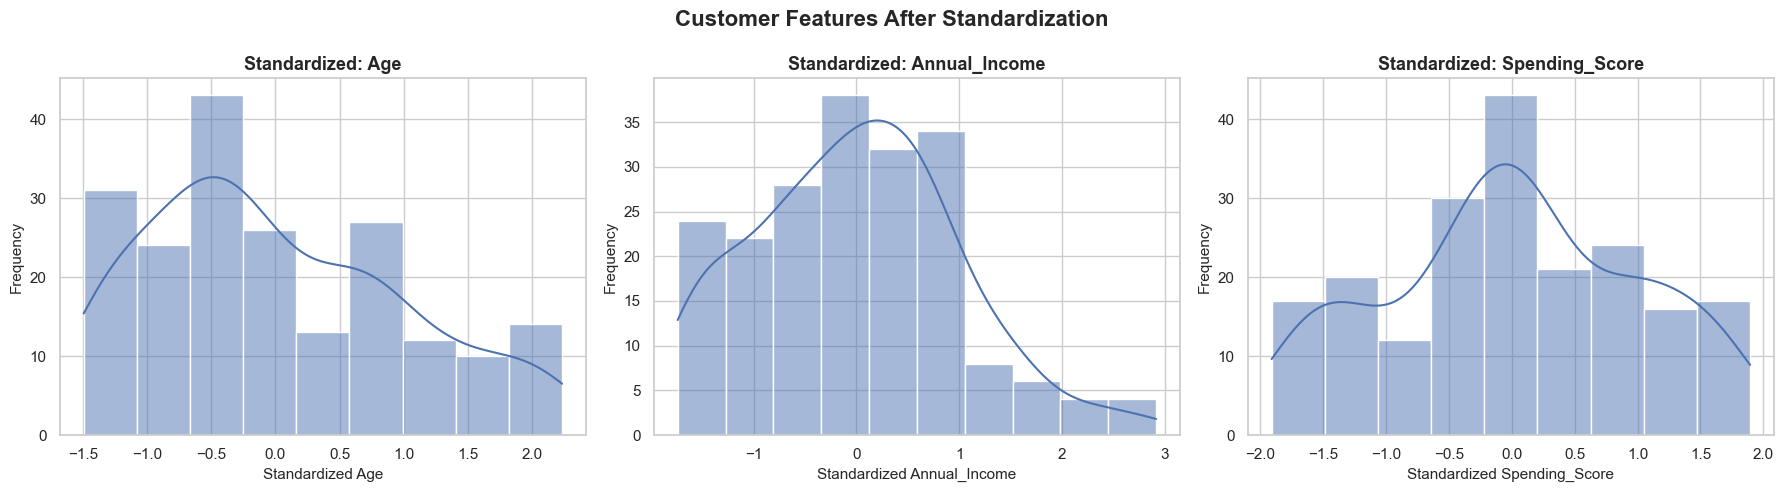

2.7 PREPROCESSING INTEGRITY CHECK

Preprocessing Integrity Summary:


,Integrity_Check,Status
0,Same Number of Rows,PASS
1,Same Number of Features,PASS
2,Same Row Index,PASS
3,Same Feature Names,PASS
4,All Features Numeric,PASS



✓ All preprocessing integrity checks passed.
✓ No observations were lost during transformation.
✓ Feature order and row alignment were preserved.
✓ The standardized matrix contains only numerical features.
✓ The clustering feature space is ready for model development.

STANDARDIZED FEATURE SPACE INSPECTION

First 10 Standardized Customer Records:


,Age,Annual_Income,Spending_Score
0,-1.43,-1.74,-0.43
1,-1.28,-1.74,1.20
2,-1.35,-1.70,-1.72
3,-1.14,-1.70,1.04
4,-0.56,-1.66,-0.40
5,-1.21,-1.66,1.00
6,-0.28,-1.62,-1.72
7,-1.14,-1.62,1.70
8,1.80,-1.59,-1.83
9,-0.64,-1.59,0.85



Standardized Feature Summary:


,count,mean,std,min,25%,50%,75%,max
Age,200.00,-0.00,1.00,-1.50,-0.72,-0.20,0.73,2.24
Annual_Income,200.00,-0.00,1.00,-1.74,-0.73,0.04,0.67,2.92
Spending_Score,200.00,-0.00,1.00,-1.91,-0.60,-0.01,0.89,1.89


STEP 2 DECISION GATE

EVIDENCE
--------

✓ Step 1 identified Age, Annual Income and Spending Score as the
  primary clustering features.

✓ CustomerID remains excluded because it is an identifier.

✓ Gender remains excluded from the primary numerical clustering space
  and will be retained for later descriptive profiling.

✓ The selected features operate on different numerical scales.

✓ The selected clustering algorithms depend on distances or
  neighbourhood relationships.

✓ StandardScaler was applied to create a comparable feature space.

✓ Standardized feature means are approximately zero.

✓ Standardized population standard deviations are approximately one.

✓ Preprocessing integrity checks passed.

✓ Original values remain available in X for later interpretation.


ANALYTICAL DECISION
-------------------

X_scaled is now the authoritative feature matrix for clustering.

The same standardized feature space will be used for:

• K-Means
• Agglomerative Hierarchical Clustering
• DBS

In [7]:
# ================================================================
# STEP 2 : FEATURE SELECTION & STANDARDIZATION
# ================================================================

# Analytical Objective:
# Convert the validated customer attributes from Step 1 into a
# consistent numerical feature space suitable for distance-based
# clustering.
#
# Analytical Logic:
#
# Step 1 Decision
#       ↓
# Final Feature Space
#       ↓
# Raw Feature Validation
#       ↓
# Scale Comparison
#       ↓
# Standardization Requirement
#       ↓
# StandardScaler Transformation
#       ↓
# Scaling Validation
#       ↓
# Preprocessing Integrity Check
#       ↓
# Clustering-Ready Feature Space
#
# The same standardized feature matrix will be used for:
#
# • K-Means
# • Agglomerative Hierarchical Clustering
# • DBSCAN
#
# This maintains a consistent feature space across all algorithms.


# ============================================================
# 2.1 CLUSTERING FEATURE SPACE DEFINITION
# ============================================================

print("=" * 75)
print("2.1 CLUSTERING FEATURE SPACE DEFINITION")
print("=" * 75)


# ------------------------------------------------------------
# Define the final clustering features selected in Step 1
# ------------------------------------------------------------

clustering_features = [
    "Age",
    "Annual_Income",
    "Spending_Score"
]


print("\nFinal Clustering Features:")

for number, feature in enumerate(
    clustering_features,
    start=1
):
    print(
        f"{number}. {feature}"
    )


# ------------------------------------------------------------
# Create the raw clustering matrix
# ------------------------------------------------------------

# X contains only the variables that will participate in
# clustering.
#
# Original customer values are preserved in X because they will
# later be required for cluster interpretation and profiling.

X = df_clean[
    clustering_features
].copy()


print("\nRaw Clustering Feature Matrix:")

display(
    X.head()
)


print(
    f"\nNumber of observations       : {X.shape[0]}"
)

print(
    f"Number of clustering features: {X.shape[1]}"
)


# ------------------------------------------------------------
# Validate feature data types
# ------------------------------------------------------------

print("\nFeature Data Types:")

display(
    X.dtypes.to_frame(
        name="Data_Type"
    )
)


# ------------------------------------------------------------
# Validate missing values
# ------------------------------------------------------------

missing_in_X = X.isnull().sum()

print("\nMissing Values in Clustering Matrix:")

display(
    missing_in_X.to_frame(
        name="Missing_Values"
    )
)


# ------------------------------------------------------------
# Raw feature summary
# ------------------------------------------------------------

raw_feature_summary = X.describe().T

print("\nRaw Feature Statistics:")

display(
    raw_feature_summary.round(2)
)


# ============================================================
# 2.2 WHY FEATURE STANDARDIZATION IS REQUIRED
# ============================================================

print("=" * 75)
print("2.2 WHY FEATURE STANDARDIZATION IS REQUIRED")
print("=" * 75)


print("""
WHY STANDARDIZATION?

The selected customer attributes are measured on different numerical
scales:

• Age → measured in years
• Annual Income → measured in thousands of dollars
• Spending Score → measured on a 1–100 scale

The clustering methods used in this project depend on distances or
neighbourhood relationships.

Therefore, differences in numerical scale can affect the contribution
of individual variables to the clustering process.

To place the selected variables on a comparable scale, StandardScaler
will be applied.

Standardization transforms each feature using:

        z = (x - mean) / standard deviation

After transformation, each feature has approximately:

        Mean = 0
        Population Standard Deviation = 1

The transformation changes the scale of the variables, but preserves
the relative ordering of observations within each feature.

IMPORTANT:

• X will preserve the original customer values.
• X_scaled will contain the standardized values.
• X_scaled will be used for clustering.
• X will be used later for customer interpretation and profiling.
""")


# ------------------------------------------------------------
# Compare original feature scales
# ------------------------------------------------------------

scale_comparison = pd.DataFrame({

    "Feature": clustering_features,

    "Minimum": [
        X[feature].min()
        for feature in clustering_features
    ],

    "Maximum": [
        X[feature].max()
        for feature in clustering_features
    ],

    "Mean": [
        X[feature].mean()
        for feature in clustering_features
    ],

    "Standard_Deviation": [
        X[feature].std()
        for feature in clustering_features
    ]

})


print("\nOriginal Feature Scale Comparison:")

display(
    scale_comparison.round(2)
)


# ------------------------------------------------------------
# Analytical scaling decision
# ------------------------------------------------------------

print("\nScaling Decision:")

if (
    scale_comparison["Maximum"].max()
    - scale_comparison["Maximum"].min()
    > 10
):

    print("""
✓ The selected features operate on noticeably different numerical scales.
✓ Standardization is required before distance-based clustering.
✓ StandardScaler will therefore be applied.
""")

else:

    print("""
✓ Feature scales are relatively similar.
✓ Standardization will still be applied to maintain a consistent
  preprocessing framework across the clustering algorithms.
""")


# ============================================================
# 2.3 STANDARDIZATION OF CUSTOMER ATTRIBUTES
# ============================================================

print("=" * 75)
print("2.3 STANDARDIZATION OF CUSTOMER ATTRIBUTES")
print("=" * 75)


# ------------------------------------------------------------
# Initialize StandardScaler
# ------------------------------------------------------------

scaler = StandardScaler()


# ------------------------------------------------------------
# Fit the scaler and transform the clustering matrix
# ------------------------------------------------------------

# The scaler is fitted only on the clustering feature matrix.
#
# No target variable is present in this unsupervised project.
# No future/test information is used.
#
# This keeps the preprocessing procedure transparent and prevents
# unnecessary preprocessing leakage.

X_scaled = scaler.fit_transform(
    X
)


# ------------------------------------------------------------
# Convert standardized values to DataFrame
# ------------------------------------------------------------

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=clustering_features,
    index=X.index
)


print("\nFirst 5 Standardized Observations:")

display(
    X_scaled_df.head().round(3)
)


# ------------------------------------------------------------
# StandardScaler parameters
# ------------------------------------------------------------

scaling_parameters = pd.DataFrame({

    "Feature": clustering_features,

    "Scaler_Mean": scaler.mean_,

    "Scaler_Scale": scaler.scale_

})


print("\nStandardScaler Parameters:")

display(
    scaling_parameters.round(4)
)


# ============================================================
# 2.4 SCALED FEATURE VALIDATION
# ============================================================

print("=" * 75)
print("2.4 SCALED FEATURE VALIDATION")
print("=" * 75)


# ------------------------------------------------------------
# Validate standardized feature properties
# ------------------------------------------------------------

# StandardScaler uses population standard deviation (ddof=0).
# Therefore, the validation below also uses ddof=0.

scaled_validation = pd.DataFrame({

    "Feature": clustering_features,

    "Mean_After_Scaling": [
        X_scaled_df[feature].mean()
        for feature in clustering_features
    ],

    "Population_Std_After_Scaling": [
        X_scaled_df[feature].std(ddof=0)
        for feature in clustering_features
    ],

    "Minimum_After_Scaling": [
        X_scaled_df[feature].min()
        for feature in clustering_features
    ],

    "Maximum_After_Scaling": [
        X_scaled_df[feature].max()
        for feature in clustering_features
    ]

})


print("\nScaled Feature Validation:")

display(
    scaled_validation.round(4)
)


# ------------------------------------------------------------
# Automated validation
# ------------------------------------------------------------

mean_check = np.allclose(
    X_scaled_df.mean().values,
    0,
    atol=1e-10
)


std_check = np.allclose(
    X_scaled_df.std(ddof=0).values,
    1,
    atol=1e-10
)


print("\nScaling Validation Decision:")


if mean_check and std_check:

    print("""
✓ Mean of each standardized feature is approximately 0.
✓ Population standard deviation of each standardized feature is 1.
✓ Standardization was successfully applied.
✓ The feature space is ready for clustering.
""")

else:

    print("""
⚠ Scaling validation failed.
The standardized feature matrix should be inspected before modelling.
""")


# ============================================================
# 2.5 RAW VS STANDARDIZED FEATURE COMPARISON
# ============================================================

print("=" * 75)
print("2.5 RAW VS STANDARDIZED FEATURE COMPARISON")
print("=" * 75)


# Compare the numerical scale before and after transformation.

comparison_table = pd.DataFrame({

    "Feature": clustering_features,

    "Raw_Mean": [
        X[feature].mean()
        for feature in clustering_features
    ],

    "Raw_Std": [
        X[feature].std()
        for feature in clustering_features
    ],

    "Scaled_Mean": [
        X_scaled_df[feature].mean()
        for feature in clustering_features
    ],

    "Scaled_Population_Std": [
        X_scaled_df[feature].std(ddof=0)
        for feature in clustering_features
    ]

})


display(
    comparison_table.round(4)
)


print("""
INTERPRETATION:

Before standardization, the customer attributes operate on different
numerical scales.

After standardization:

✓ Feature means are approximately 0.
✓ Population standard deviations are approximately 1.
✓ No selected feature is given dominance simply because of its original
  measurement scale.

Therefore, the transformed matrix is appropriate for distance-based
clustering.
""")


# ============================================================
# 2.6 VISUAL VALIDATION OF STANDARDIZATION
# ============================================================

print("=" * 75)
print("2.6 VISUAL VALIDATION OF STANDARDIZATION")
print("=" * 75)


# ------------------------------------------------------------
# Raw feature distributions
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)


for ax, feature in zip(
    axes,
    clustering_features
):

    sns.histplot(
        X[feature],
        kde=True,
        ax=ax
    )

    ax.set_title(
        f"Raw: {feature}",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")


plt.suptitle(
    "Customer Features Before Standardization",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Standardized feature distributions
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)


for ax, feature in zip(
    axes,
    clustering_features
):

    sns.histplot(
        X_scaled_df[feature],
        kde=True,
        ax=ax
    )

    ax.set_title(
        f"Standardized: {feature}",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(
        f"Standardized {feature}"
    )

    ax.set_ylabel("Frequency")


plt.suptitle(
    "Customer Features After Standardization",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 2.7 PREPROCESSING INTEGRITY CHECK
# ============================================================

print("=" * 75)
print("2.7 PREPROCESSING INTEGRITY CHECK")
print("=" * 75)


# ------------------------------------------------------------
# Confirm dimensions are unchanged
# ------------------------------------------------------------

shape_check = (
    X.shape == X_scaled_df.shape
)


# ------------------------------------------------------------
# Confirm row alignment is unchanged
# ------------------------------------------------------------

index_check = (
    X.index.equals(
        X_scaled_df.index
    )
)


# ------------------------------------------------------------
# Confirm feature names are unchanged
# ------------------------------------------------------------

feature_check = (
    list(X.columns)
    == list(X_scaled_df.columns)
)


# ------------------------------------------------------------
# Confirm all standardized values are numeric
# ------------------------------------------------------------

numeric_check = all(
    pd.api.types.is_numeric_dtype(
        X_scaled_df[column]
    )
    for column in X_scaled_df.columns
)


integrity_summary = pd.DataFrame({

    "Integrity_Check": [
        "Same Number of Rows",
        "Same Number of Features",
        "Same Row Index",
        "Same Feature Names",
        "All Features Numeric"
    ],

    "Status": [
        "PASS" if shape_check else "FAIL",
        "PASS" if shape_check else "FAIL",
        "PASS" if index_check else "FAIL",
        "PASS" if feature_check else "FAIL",
        "PASS" if numeric_check else "FAIL"
    ]

})


print("\nPreprocessing Integrity Summary:")

display(
    integrity_summary
)


all_checks_pass = (
    shape_check
    and index_check
    and feature_check
    and numeric_check
    and mean_check
    and std_check
)


if all_checks_pass:

    print("""
✓ All preprocessing integrity checks passed.
✓ No observations were lost during transformation.
✓ Feature order and row alignment were preserved.
✓ The standardized matrix contains only numerical features.
✓ The clustering feature space is ready for model development.
""")

else:

    print("""
⚠ One or more preprocessing checks failed.
Review the results before continuing to clustering.
""")


# ============================================================
# STANDARDIZED FEATURE SPACE INSPECTION
# ============================================================

print("=" * 75)
print("STANDARDIZED FEATURE SPACE INSPECTION")
print("=" * 75)


print("\nFirst 10 Standardized Customer Records:")

display(
    X_scaled_df
    .head(10)
    .round(3)
)


print("\nStandardized Feature Summary:")

display(
    X_scaled_df
    .describe()
    .T
    .round(3)
)


# ============================================================
# STEP 2 DECISION GATE
# ============================================================

print("=" * 75)
print("STEP 2 DECISION GATE")
print("=" * 75)


print("""
EVIDENCE
--------

✓ Step 1 identified Age, Annual Income and Spending Score as the
  primary clustering features.

✓ CustomerID remains excluded because it is an identifier.

✓ Gender remains excluded from the primary numerical clustering space
  and will be retained for later descriptive profiling.

✓ The selected features operate on different numerical scales.

✓ The selected clustering algorithms depend on distances or
  neighbourhood relationships.

✓ StandardScaler was applied to create a comparable feature space.

✓ Standardized feature means are approximately zero.

✓ Standardized population standard deviations are approximately one.

✓ Preprocessing integrity checks passed.

✓ Original values remain available in X for later interpretation.


ANALYTICAL DECISION
-------------------

X_scaled is now the authoritative feature matrix for clustering.

The same standardized feature space will be used for:

• K-Means
• Agglomerative Hierarchical Clustering
• DBSCAN

This maintains methodological consistency when comparing the algorithms.


NEXT ANALYTICAL QUESTION
------------------------

The preprocessing stage is complete.

The next question is not:

"What cluster number do we already know?"

Instead:

"What number of customer groups provides a meaningful partition of the
standardized customer feature space?"

This will be investigated empirically using:

• Elbow Method
• Silhouette Analysis

before fitting the final K-Means model.
""")


# ============================================================
# STEP 2 ANALYTICAL CONCLUSION
# ============================================================

print("=" * 75)
print("STEP 2 ANALYTICAL CONCLUSION")
print("=" * 75)


print("""
FEATURE SPACE
-------------

✓ Age
✓ Annual Income
✓ Spending Score


PREPROCESSING
-------------

✓ Raw clustering matrix X was created.
✓ Original feature values were preserved.
✓ StandardScaler was applied.
✓ Standardized feature matrix X_scaled was created.


VALIDATION
----------

✓ Standardized feature means are approximately 0.
✓ Standardized population standard deviations are approximately 1.
✓ Feature names and row alignment were preserved.
✓ No observations were lost during transformation.
✓ All preprocessing integrity checks passed.


MODELING CONSISTENCY
--------------------

✓ X_scaled will be used for K-Means.
✓ X_scaled will be used for Agglomerative Clustering.
✓ X_scaled will be used for DBSCAN.

This ensures that all three algorithms operate on the same standardized
feature space.


ANALYTICAL TRANSITION
---------------------

Step 1 established WHAT customer attributes should be clustered.

Step 2 established HOW those attributes should be represented for
distance-based clustering.

Step 3 will investigate HOW MANY customer groups can be identified
using K-Means.
""")


# ============================================================
# STEP 2 COMPLETED
# ============================================================

print("=" * 75)
print("STEP 2 COMPLETED : FEATURE SPACE → STANDARDIZATION → VALIDATION")
print("=" * 75)


print("""
✓ Feature Space Defined
✓ Raw Feature Matrix Created
✓ Scaling Requirement Established
✓ StandardScaler Applied
✓ Scaling Validated
✓ Preprocessing Integrity Checked
✓ Original Values Preserved for Interpretation
✓ Standardized Feature Matrix Ready
✓ Common Feature Space Established for All Algorithms

READY FOR STEP 3:

K-MEANS CLUSTERING & OPTIMAL CLUSTER SELECTION

Next:
Elbow Method → Silhouette Analysis → Final K-Means Model
""")

3.1 K-MEANS CLUSTERING STRATEGY

ANALYTICAL OBJECTIVE
---------------------------------------------------------------------------
Determine a meaningful number of customer segments from the standardized customer feature space.

CLUSTERING FEATURE SPACE
---------------------------------------------------------------------------
Number of observations : 200
Number of features    : 3
Features               : ['Age', 'Annual_Income', 'Spending_Score']

MODELLING MATRIX
---------------------------------------------------------------------------
Primary matrix         : X_scaled
Original matrix        : X
Standardization        : StandardScaler
Random state            : 42
Candidate K values     : 2 to 10

METHODOLOGICAL DECISION
---------------------------------------------------------------------------
✓ K will not be assumed in advance.
✓ Multiple candidate K values will be evaluated.
✓ Elbow Method will assess within-cluster variation.
✓ Silhouette Analysis will assess cluster cohesion a

,Number_of_Clusters,Inertia
0,2,389.39
1,3,295.21
2,4,205.23
3,5,168.25
4,6,133.87
5,7,117.01
6,8,103.87
7,9,93.09
8,10,82.39


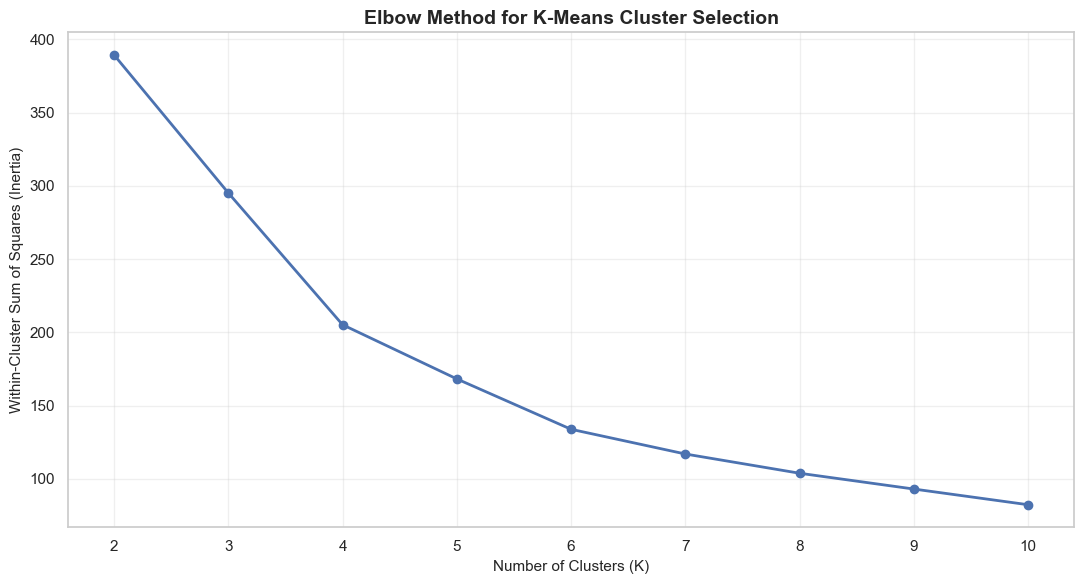


ELBOW METHOD INTERPRETATION
---------------------------------------------------------------------------
The elbow plot is used to identify the region where increasing K produces progressively smaller reductions in inertia.
The elbow provides structural evidence, but it will not be used as the sole criterion for selecting the final number of clusters.


3.3 SILHOUETTE ANALYSIS

ANALYTICAL PURPOSE
---------------------------------------------------------------------------
Evaluate how well-separated and internally cohesive the candidate K-Means solutions are.

K-MEANS CANDIDATE EVALUATION
---------------------------------------------------------------------------


,Number_of_Clusters,Inertia,Silhouette_Score
0,2,389.39,0.3355
1,3,295.21,0.3578
2,4,205.23,0.4040
3,5,168.25,0.4166
4,6,133.87,0.4284
5,7,117.01,0.4172
6,8,103.87,0.4082
7,9,93.09,0.4177
8,10,82.39,0.4066



BEST SILHOUETTE RESULT
---------------------------------------------------------------------------
Highest Silhouette Score : 0.4284
Corresponding K          : 6


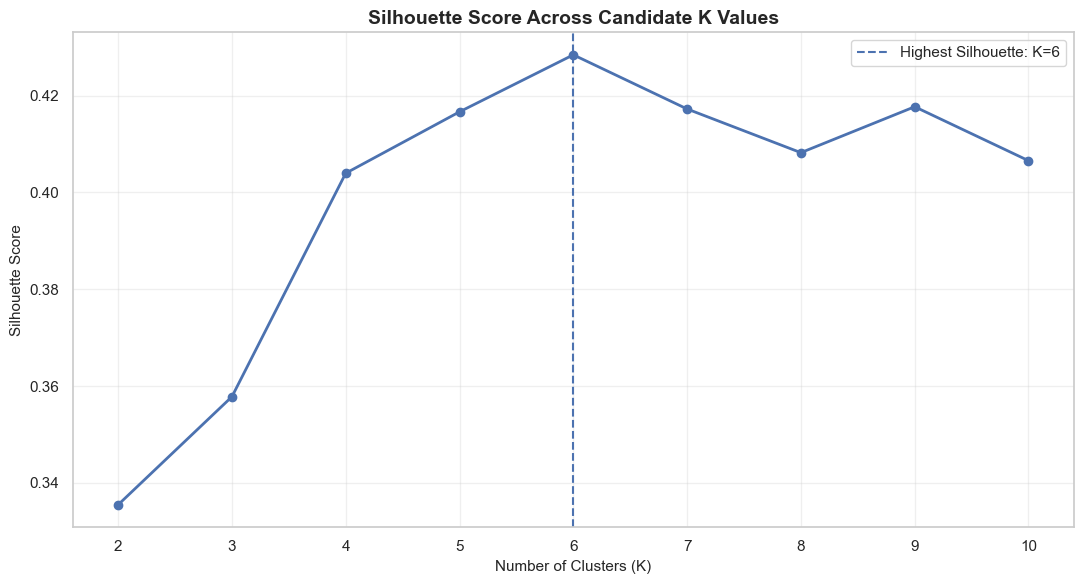



3.4 FINAL K-MEANS MODEL DEVELOPMENT

MODEL SELECTION LOGIC
---------------------------------------------------------------------------
The highest Silhouette Score provides a quantitative candidate for K, while the Elbow Method provides complementary structural evidence.

Selected K based on Silhouette evidence: 6

FINAL K-MEANS MODEL
---------------------------------------------------------------------------
Algorithm              : K-Means
Selected clusters (K)  : 6
Observations           : 200
Features               : 3
Final inertia          : 133.87
Final silhouette score : 0.4284

✓ Final K-Means model fitted successfully.
✓ Cluster labels generated for all observations.


3.5 K-MEANS CLUSTER VISUALIZATION

VISUALIZATION PURPOSE
---------------------------------------------------------------------------
Visualize the resulting customer segments using Annual Income and Spending Score while preserving Age as part of the model.


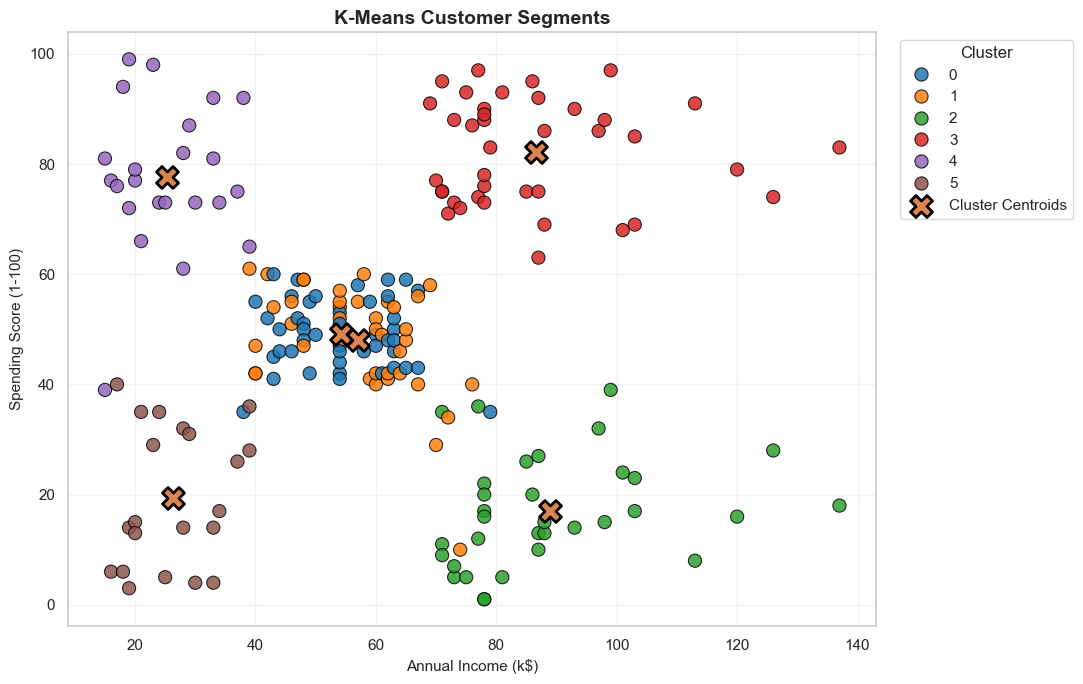

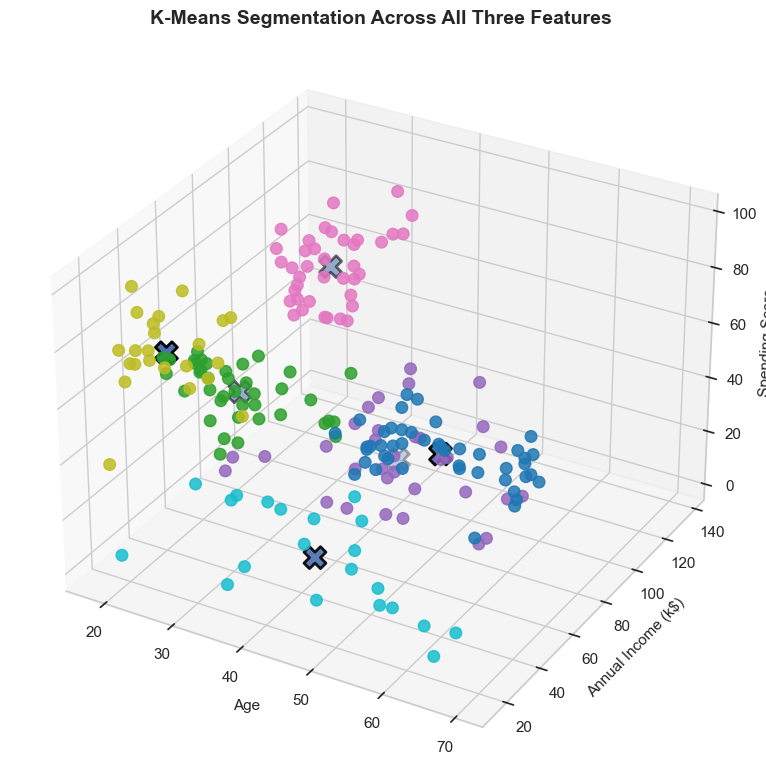



3.6 K-MEANS CLUSTER PROFILING

ANALYTICAL PURPOSE
---------------------------------------------------------------------------
Describe the behavioural characteristics of each customer segment using the original feature units.

CUSTOMER SEGMENT PROFILE
---------------------------------------------------------------------------


Age                      Annual_Income                       Spending_Score                     
        count  mean median min max         count  mean median min  max          count  mean median min max
Cluster                                                                                                   
0          45 56.33  54.00  43  70            45 54.27  54.00  38   79             45 49.07  49.00  35  60
1          39 26.79  26.00  18  40            39 57.10  60.00  39   76             39 48.13  50.00  10  61
2          33 41.94  43.00  19  59            33 88.94  86.00  71  137             33 16.97  16.00   1  39
3          39 32.69  32.00  27  40            39 86.54  79.00  69  137             39 82.13  83.00  63  97
4          23 25.00  23.00  18  35            23 25.26  24.00  15   39             23 77.61  77.00  39  99
5          21 45.52  46.00  20  67            21 26.29  25.00  16   39             21 19.38  15.00   3  40


BUSINESS-READY CLUSTER SUMMARY
---------------------------------------------------------------------------


,Cluster,Customer_Count,Average_Age,Average_Annual_Income,Average_Spending_Score,Customer_Percentage
0,0,45,56.33,54.27,49.07,22.50%
1,1,39,26.79,57.10,48.13,19.50%
2,2,33,41.94,88.94,16.97,16.50%
3,3,39,32.69,86.54,82.13,19.50%
4,4,23,25.00,25.26,77.61,11.50%
5,5,21,45.52,26.29,19.38,10.50%



GENDER DISTRIBUTION WITHIN CLUSTERS
---------------------------------------------------------------------------
Note: Gender is used only for descriptive profiling and was not used to create the clusters.


Gender,Female,Male
Cluster,,
0,57.78,42.22
1,64.10,35.90
2,42.42,57.58
3,53.85,46.15
4,56.52,43.48
5,61.90,38.10



K-MEANS CENTROIDS IN ORIGINAL UNITS
---------------------------------------------------------------------------


,Age,Annual_Income,Spending_Score
Cluster,,,
0,56.33,54.27,49.07
1,26.79,57.10,48.13
2,41.94,88.94,16.97
3,32.69,86.54,82.13
4,25.00,25.26,77.61
5,45.52,26.29,19.38




3.7 K-MEANS CLUSTER SIZE VALIDATION

ANALYTICAL PURPOSE
---------------------------------------------------------------------------
Check whether the resulting customer segments contain a meaningful number of observations rather than being dominated by extremely small or extremely large groups.

CLUSTER SIZE DISTRIBUTION
---------------------------------------------------------------------------


,Cluster,Customer_Count,Customer_Percentage
0,0,45,22.50%
1,1,39,19.50%
2,2,33,16.50%
3,3,39,19.50%
4,4,23,11.50%
5,5,21,10.50%


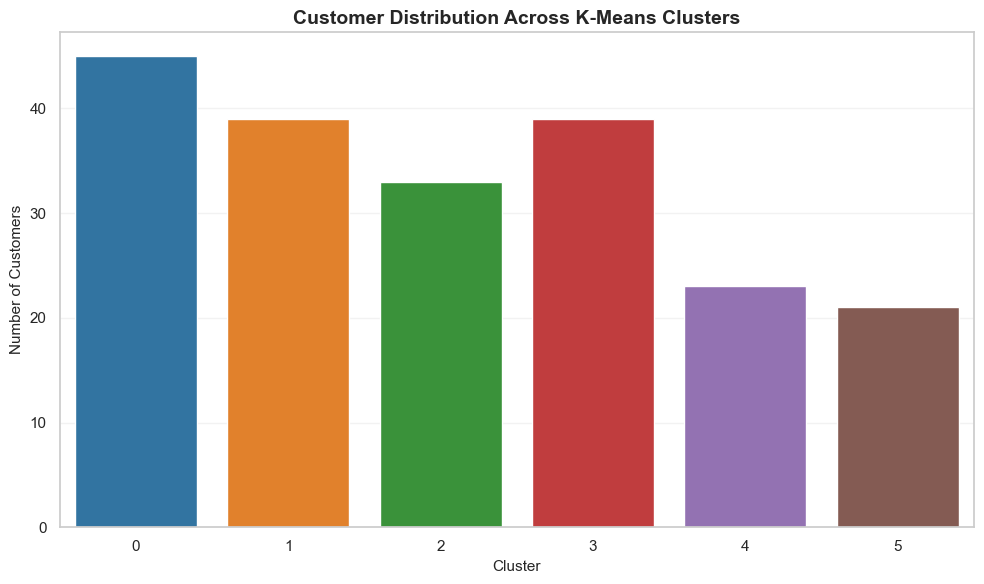



STEP 3 DECISION GATE

EVIDENCE
---------------------------------------------------------------------------
✓ K-Means was evaluated across candidate K values from 2 to 10.
✓ Elbow Method was used to assess within-cluster variation.
✓ Silhouette Analysis was used to assess cluster quality.
✓ Highest Silhouette Score occurred at K = 6.
✓ Final K-Means model was developed using K = 6.
✓ Original customer units were retained for interpretation.
✓ Cluster profiles were generated.
✓ Cluster sizes were validated.

ANALYTICAL DECISION
---------------------------------------------------------------------------
The current K-Means segmentation uses 6 customer clusters based on the quantitative Silhouette evidence and the structural evidence from the Elbow Method.

The cluster labels represent mathematically derived groups and will not be assigned business names until their behavioural profiles are examined.

NEXT ANALYTICAL QUESTION
--------------------------------------------------------------

In [8]:
# ============================================================
# STEP 3 : K-MEANS CLUSTERING & OPTIMAL CLUSTER SELECTION
# ============================================================
#
# Analytical Objective:
# Determine a meaningful number of customer segments using
# K-Means clustering and validate the resulting segmentation
# using Elbow Method, Silhouette Analysis, cluster profiling,
# and cluster-size validation.
#
# Important:
# X_scaled from Step 2 is the authoritative modelling matrix.
# X is retained for interpretation in the original units.
# ============================================================


# ============================================================
# 3.1 K-MEANS CLUSTERING STRATEGY
# ============================================================

print("=" * 75)
print("3.1 K-MEANS CLUSTERING STRATEGY")
print("=" * 75)

print("\nANALYTICAL OBJECTIVE")
print("-" * 75)
print(
    "Determine a meaningful number of customer segments from the "
    "standardized customer feature space."
)

print("\nCLUSTERING FEATURE SPACE")
print("-" * 75)

print(f"Number of observations : {X_scaled.shape[0]}")
print(f"Number of features    : {X_scaled.shape[1]}")
print(f"Features               : {clustering_features}")

print("\nMODELLING MATRIX")
print("-" * 75)
print("Primary matrix         : X_scaled")
print("Original matrix        : X")
print("Standardization        : StandardScaler")
print("Random state            :", RANDOM_STATE)
print("Candidate K values     : 2 to 10")

print("\nMETHODOLOGICAL DECISION")
print("-" * 75)
print("✓ K will not be assumed in advance.")
print("✓ Multiple candidate K values will be evaluated.")
print("✓ Elbow Method will assess within-cluster variation.")
print("✓ Silhouette Analysis will assess cluster cohesion and separation.")
print("✓ Final K will be selected using combined analytical evidence.")


# ============================================================
# 3.2 ELBOW METHOD FOR OPTIMAL CLUSTER SELECTION
# ============================================================

print("\n\n" + "=" * 75)
print("3.2 ELBOW METHOD FOR OPTIMAL CLUSTER SELECTION")
print("=" * 75)

print("\nANALYTICAL PURPOSE")
print("-" * 75)
print(
    "Evaluate how within-cluster variation changes as the number "
    "of clusters increases."
)

# ------------------------------------------------------------
# Candidate cluster counts
# ------------------------------------------------------------

k_values = list(range(2, 11))

inertia_values = []

# ------------------------------------------------------------
# Fit K-Means for every candidate K
# ------------------------------------------------------------

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    model.fit(X_scaled)

    inertia_values.append(model.inertia_)

# ------------------------------------------------------------
# Create Elbow Method results table
# ------------------------------------------------------------

elbow_results = pd.DataFrame({
    "Number_of_Clusters": k_values,
    "Inertia": inertia_values
})

print("\nK-MEANS INERTIA RESULTS")
print("-" * 75)

display(
    elbow_results.style
    .format({
        "Inertia": "{:,.2f}"
    })
)

# ------------------------------------------------------------
# Elbow visualization
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.plot(
    k_values,
    inertia_values,
    marker="o",
    linewidth=2
)

plt.title(
    "Elbow Method for K-Means Cluster Selection",
    fontweight="bold"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.xticks(k_values)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nELBOW METHOD INTERPRETATION")
print("-" * 75)
print(
    "The elbow plot is used to identify the region where increasing K "
    "produces progressively smaller reductions in inertia."
)
print(
    "The elbow provides structural evidence, but it will not be used "
    "as the sole criterion for selecting the final number of clusters."
)


# ============================================================
# 3.3 SILHOUETTE ANALYSIS
# ============================================================

print("\n\n" + "=" * 75)
print("3.3 SILHOUETTE ANALYSIS")
print("=" * 75)

print("\nANALYTICAL PURPOSE")
print("-" * 75)
print(
    "Evaluate how well-separated and internally cohesive the candidate "
    "K-Means solutions are."
)

# ------------------------------------------------------------
# Calculate Silhouette Score for every candidate K
# ------------------------------------------------------------

silhouette_values = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_values.append(score)

# ------------------------------------------------------------
# Create combined model-selection table
# ------------------------------------------------------------

k_evaluation = pd.DataFrame({
    "Number_of_Clusters": k_values,
    "Inertia": inertia_values,
    "Silhouette_Score": silhouette_values
})

print("\nK-MEANS CANDIDATE EVALUATION")
print("-" * 75)

display(
    k_evaluation.style
    .format({
        "Inertia": "{:,.2f}",
        "Silhouette_Score": "{:.4f}"
    })
)

# ------------------------------------------------------------
# Identify the K with the highest Silhouette Score
# ------------------------------------------------------------

best_silhouette_k = int(
    k_evaluation.loc[
        k_evaluation["Silhouette_Score"].idxmax(),
        "Number_of_Clusters"
    ]
)

best_silhouette_score = float(
    k_evaluation["Silhouette_Score"].max()
)

print("\nBEST SILHOUETTE RESULT")
print("-" * 75)
print(f"Highest Silhouette Score : {best_silhouette_score:.4f}")
print(f"Corresponding K          : {best_silhouette_k}")

# ------------------------------------------------------------
# Silhouette Score visualization
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.plot(
    k_values,
    silhouette_values,
    marker="o",
    linewidth=2
)

plt.axvline(
    best_silhouette_k,
    linestyle="--",
    linewidth=1.5,
    label=f"Highest Silhouette: K={best_silhouette_k}"
)

plt.title(
    "Silhouette Score Across Candidate K Values",
    fontweight="bold"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 3.4 FINAL K-MEANS MODEL DEVELOPMENT
# ============================================================

print("\n\n" + "=" * 75)
print("3.4 FINAL K-MEANS MODEL DEVELOPMENT")
print("=" * 75)

print("\nMODEL SELECTION LOGIC")
print("-" * 75)
print(
    "The highest Silhouette Score provides a quantitative candidate "
    "for K, while the Elbow Method provides complementary structural "
    "evidence."
)

# ------------------------------------------------------------
# Initial final-K selection
#
# The highest Silhouette Score is used as the quantitative
# selection criterion. The Elbow plot should be inspected
# alongside this result.
# ------------------------------------------------------------

optimal_k = best_silhouette_k

print(f"\nSelected K based on Silhouette evidence: {optimal_k}")

# ------------------------------------------------------------
# Train final K-Means model
# ------------------------------------------------------------

final_kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=RANDOM_STATE,
    n_init=10
)

kmeans_labels = final_kmeans.fit_predict(X_scaled)

# ------------------------------------------------------------
# Store cluster labels separately
# ------------------------------------------------------------

kmeans_clustered_data = X.copy()

kmeans_clustered_data["Cluster"] = kmeans_labels

# ------------------------------------------------------------
# Final model information
# ------------------------------------------------------------

print("\nFINAL K-MEANS MODEL")
print("-" * 75)

print(f"Algorithm              : K-Means")
print(f"Selected clusters (K)  : {optimal_k}")
print(f"Observations           : {X_scaled.shape[0]}")
print(f"Features               : {X_scaled.shape[1]}")
print(f"Final inertia          : {final_kmeans.inertia_:,.2f}")
print(
    f"Final silhouette score : "
    f"{silhouette_score(X_scaled, kmeans_labels):.4f}"
)

print("\n✓ Final K-Means model fitted successfully.")
print("✓ Cluster labels generated for all observations.")


# ============================================================
# 3.5 K-MEANS CLUSTER VISUALIZATION
# ============================================================

print("\n\n" + "=" * 75)
print("3.5 K-MEANS CLUSTER VISUALIZATION")
print("=" * 75)

print("\nVISUALIZATION PURPOSE")
print("-" * 75)
print(
    "Visualize the resulting customer segments using Annual Income "
    "and Spending Score while preserving Age as part of the model."
)

# ------------------------------------------------------------
# Create a 2D business-oriented visualization
# ------------------------------------------------------------

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=kmeans_clustered_data,
    x="Annual_Income",
    y="Spending_Score",
    hue="Cluster",
    palette="tab10",
    s=90,
    alpha=0.85,
    edgecolor="black"
)

# ------------------------------------------------------------
# Transform K-Means centroids back to original units
# ------------------------------------------------------------

centroids_original = scaler.inverse_transform(
    final_kmeans.cluster_centers_
)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=clustering_features
)

# ------------------------------------------------------------
# Plot cluster centroids in the same 2D business space
# ------------------------------------------------------------

plt.scatter(
    centroids_df["Annual_Income"],
    centroids_df["Spending_Score"],
    marker="X",
    s=250,
    linewidth=2,
    edgecolor="black",
    label="Cluster Centroids"
)

plt.title(
    "K-Means Customer Segments",
    fontweight="bold"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3D visualization using all three clustering variables
# ------------------------------------------------------------

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    kmeans_clustered_data["Age"],
    kmeans_clustered_data["Annual_Income"],
    kmeans_clustered_data["Spending_Score"],
    c=kmeans_clustered_data["Cluster"],
    cmap="tab10",
    s=70,
    alpha=0.85
)

ax.scatter(
    centroids_df["Age"],
    centroids_df["Annual_Income"],
    centroids_df["Spending_Score"],
    marker="X",
    s=250,
    edgecolor="black",
    linewidth=2
)

ax.set_title(
    "K-Means Segmentation Across All Three Features",
    fontweight="bold"
)

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score")

plt.tight_layout()
plt.show()


# ============================================================
# 3.6 K-MEANS CLUSTER PROFILING
# ============================================================

print("\n\n" + "=" * 75)
print("3.6 K-MEANS CLUSTER PROFILING")
print("=" * 75)

print("\nANALYTICAL PURPOSE")
print("-" * 75)
print(
    "Describe the behavioural characteristics of each customer segment "
    "using the original feature units."
)

# ------------------------------------------------------------
# Calculate cluster-level descriptive statistics
# ------------------------------------------------------------

cluster_profile = (
    kmeans_clustered_data
    .groupby("Cluster")[clustering_features]
    .agg(["count", "mean", "median", "min", "max"])
)

print("\nCUSTOMER SEGMENT PROFILE")
print("-" * 75)

display(
    cluster_profile.round(2)
)

# ------------------------------------------------------------
# Create a simpler business-readable profile table
# ------------------------------------------------------------

cluster_summary = (
    kmeans_clustered_data
    .groupby("Cluster")
    .agg(
        Customer_Count=("Cluster", "size"),
        Average_Age=("Age", "mean"),
        Average_Annual_Income=("Annual_Income", "mean"),
        Average_Spending_Score=("Spending_Score", "mean")
    )
    .reset_index()
)

cluster_summary["Customer_Percentage"] = (
    cluster_summary["Customer_Count"]
    / len(kmeans_clustered_data)
    * 100
)

print("\nBUSINESS-READY CLUSTER SUMMARY")
print("-" * 75)

display(
    cluster_summary.style.format({
        "Average_Age": "{:.2f}",
        "Average_Annual_Income": "{:.2f}",
        "Average_Spending_Score": "{:.2f}",
        "Customer_Percentage": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# Add Gender distribution for descriptive profiling only.
# Gender is NOT part of the clustering feature space.
# ------------------------------------------------------------

gender_profile = pd.crosstab(
    kmeans_clustered_data["Cluster"],
    df_clean["Gender"],
    normalize="index"
) * 100

print("\nGENDER DISTRIBUTION WITHIN CLUSTERS")
print("-" * 75)
print(
    "Note: Gender is used only for descriptive profiling and was not "
    "used to create the clusters."
)

display(
    gender_profile.round(2)
)

# ------------------------------------------------------------
# Display K-Means centroids in original units
# ------------------------------------------------------------

centroid_profile = pd.DataFrame(
    centroids_original,
    columns=clustering_features
)

centroid_profile.index.name = "Cluster"

print("\nK-MEANS CENTROIDS IN ORIGINAL UNITS")
print("-" * 75)

display(
    centroid_profile.round(2)
)


# ============================================================
# 3.7 K-MEANS CLUSTER SIZE VALIDATION
# ============================================================

print("\n\n" + "=" * 75)
print("3.7 K-MEANS CLUSTER SIZE VALIDATION")
print("=" * 75)

print("\nANALYTICAL PURPOSE")
print("-" * 75)
print(
    "Check whether the resulting customer segments contain a meaningful "
    "number of observations rather than being dominated by extremely "
    "small or extremely large groups."
)

cluster_sizes = (
    kmeans_clustered_data["Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_sizes.columns = [
    "Cluster",
    "Customer_Count"
]

cluster_sizes["Customer_Percentage"] = (
    cluster_sizes["Customer_Count"]
    / len(kmeans_clustered_data)
    * 100
)

print("\nCLUSTER SIZE DISTRIBUTION")
print("-" * 75)

display(
    cluster_sizes.style.format({
        "Customer_Percentage": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# Cluster-size visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=cluster_sizes,
    x="Cluster",
    y="Customer_Count",
    hue="Cluster",
    palette="tab10",
    legend=False
)

plt.title(
    "Customer Distribution Across K-Means Clusters",
    fontweight="bold"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


# ============================================================
# STEP 3 DECISION GATE
# ============================================================

print("\n\n" + "=" * 75)
print("STEP 3 DECISION GATE")
print("=" * 75)

print("\nEVIDENCE")
print("-" * 75)

print("✓ K-Means was evaluated across candidate K values from 2 to 10.")
print("✓ Elbow Method was used to assess within-cluster variation.")
print("✓ Silhouette Analysis was used to assess cluster quality.")
print(f"✓ Highest Silhouette Score occurred at K = {best_silhouette_k}.")
print(f"✓ Final K-Means model was developed using K = {optimal_k}.")
print("✓ Original customer units were retained for interpretation.")
print("✓ Cluster profiles were generated.")
print("✓ Cluster sizes were validated.")

print("\nANALYTICAL DECISION")
print("-" * 75)

print(
    f"The current K-Means segmentation uses {optimal_k} customer clusters "
    "based on the quantitative Silhouette evidence and the structural "
    "evidence from the Elbow Method."
)

print(
    "\nThe cluster labels represent mathematically derived groups and "
    "will not be assigned business names until their behavioural profiles "
    "are examined."
)

print("\nNEXT ANALYTICAL QUESTION")
print("-" * 75)

print(
    "Does another clustering approach identify a similar or different "
    "customer structure?"
)

print(
    "\nThis question will be investigated in Step 4 using "
    "Agglomerative Hierarchical Clustering."
)


# ============================================================
# STEP 3 ANALYTICAL CONCLUSION
# ============================================================

print("\n\n" + "=" * 75)
print("STEP 3 ANALYTICAL CONCLUSION")
print("=" * 75)

print("\nK-MEANS ANALYSIS")
print("-" * 75)

print(f"✓ Candidate K values evaluated : {k_values[0]} to {k_values[-1]}")
print(f"✓ Selected K                   : {optimal_k}")
print(f"✓ Final inertia                : {final_kmeans.inertia_:,.2f}")
print(
    f"✓ Final silhouette score       : "
    f"{silhouette_score(X_scaled, kmeans_labels):.4f}"
)

print("\nCUSTOMER SEGMENTATION")
print("-" * 75)

print(
    f"✓ {optimal_k} customer segments were generated."
)
print("✓ Cluster profiles were calculated using original customer units.")
print("✓ Cluster sizes were examined.")
print("✓ Gender was retained only for descriptive profiling.")

print("\nMODELLING CONSISTENCY")
print("-" * 75)

print("✓ X_scaled remains the standardized modelling matrix.")
print("✓ X remains the original interpretation matrix.")
print("✓ No additional feature transformation was introduced.")

print("\nANALYTICAL TRANSITION")
print("-" * 75)

print(
    "Step 2 established HOW customer attributes should be represented."
)

print(
    "Step 3 established a K-Means-based customer segmentation and "
    "investigated HOW MANY groups are supported by the data."
)

print(
    "Step 4 will investigate whether hierarchical clustering reveals "
    "a comparable customer structure."
)


# ============================================================
# STEP 3 COMPLETED
# ============================================================

print("\n\n" + "=" * 75)
print("STEP 3 COMPLETED : K-MEANS SEGMENTATION")
print("=" * 75)

print("✓ K-Means Strategy Defined")
print("✓ Candidate K Values Evaluated")
print("✓ Elbow Method Completed")
print("✓ Silhouette Analysis Completed")
print("✓ Final K-Means Model Developed")
print("✓ Customer Segments Visualized")
print("✓ Cluster Profiles Generated")
print("✓ Cluster Sizes Validated")
print("✓ Decision Gate Completed")
print("✓ Analytical Conclusion Completed")

print("\nREADY FOR STEP 4:")
print("AGGLOMERATIVE HIERARCHICAL CLUSTERING")


4.1 HIERARCHICAL CLUSTERING STRATEGY

ANALYTICAL OBJECTIVE
---------------------------------------------------------------------------
Investigate whether a hierarchical clustering approach identifies a comparable customer structure to the K-Means segmentation.

REFERENCE FEATURE SPACE
---------------------------------------------------------------------------
Number of observations : 200
Number of features    : 3
Features               : ['Age', 'Annual_Income', 'Spending_Score']

MODELLING MATRIX
---------------------------------------------------------------------------
Primary matrix         : X_scaled
Original matrix        : X
Standardization        : StandardScaler
Reference K from Step 3: 6

HIERARCHICAL CLUSTERING CONFIGURATION
---------------------------------------------------------------------------
Algorithm              : Agglomerative Hierarchical Clustering
Linkage method         : Ward
Distance metric        : Euclidean
Number of clusters     : 6

METHODOLOGICAL DECISI

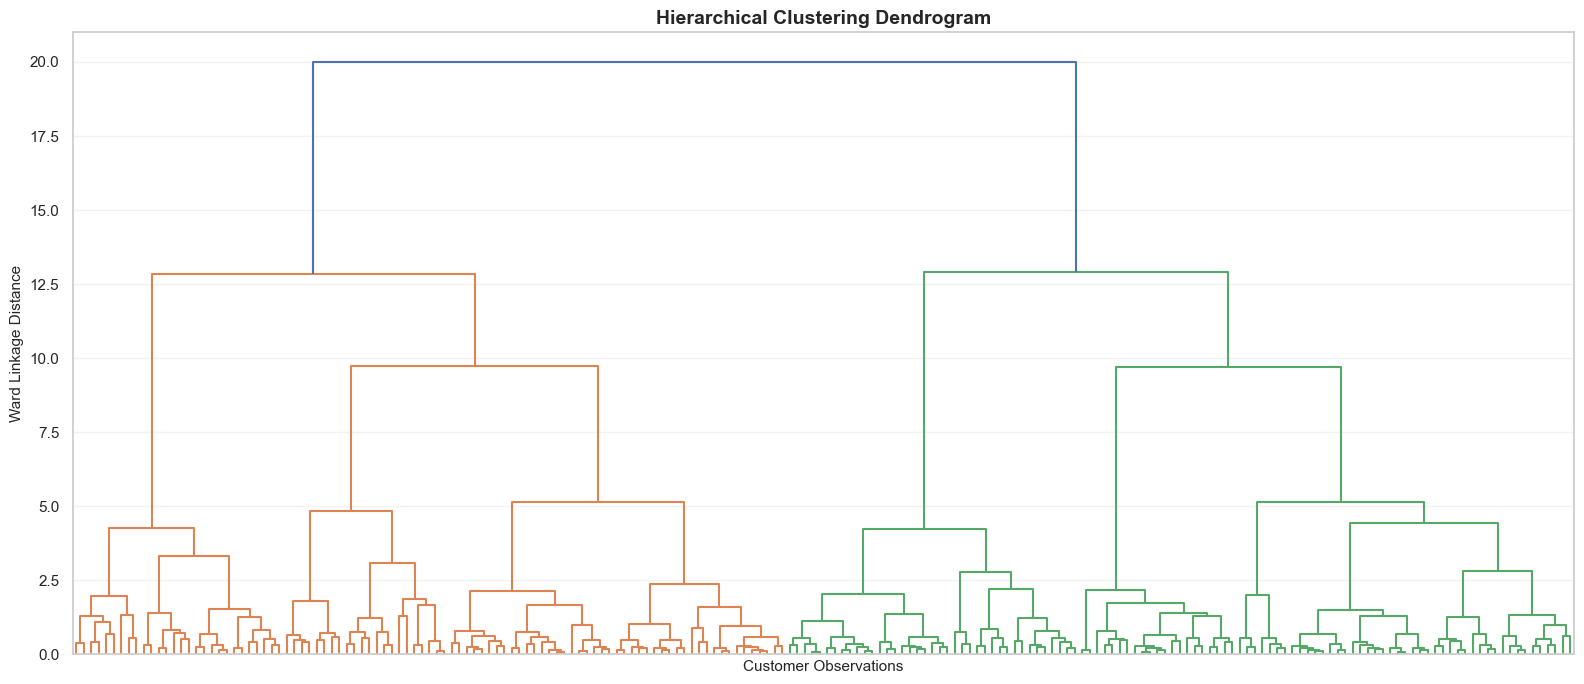

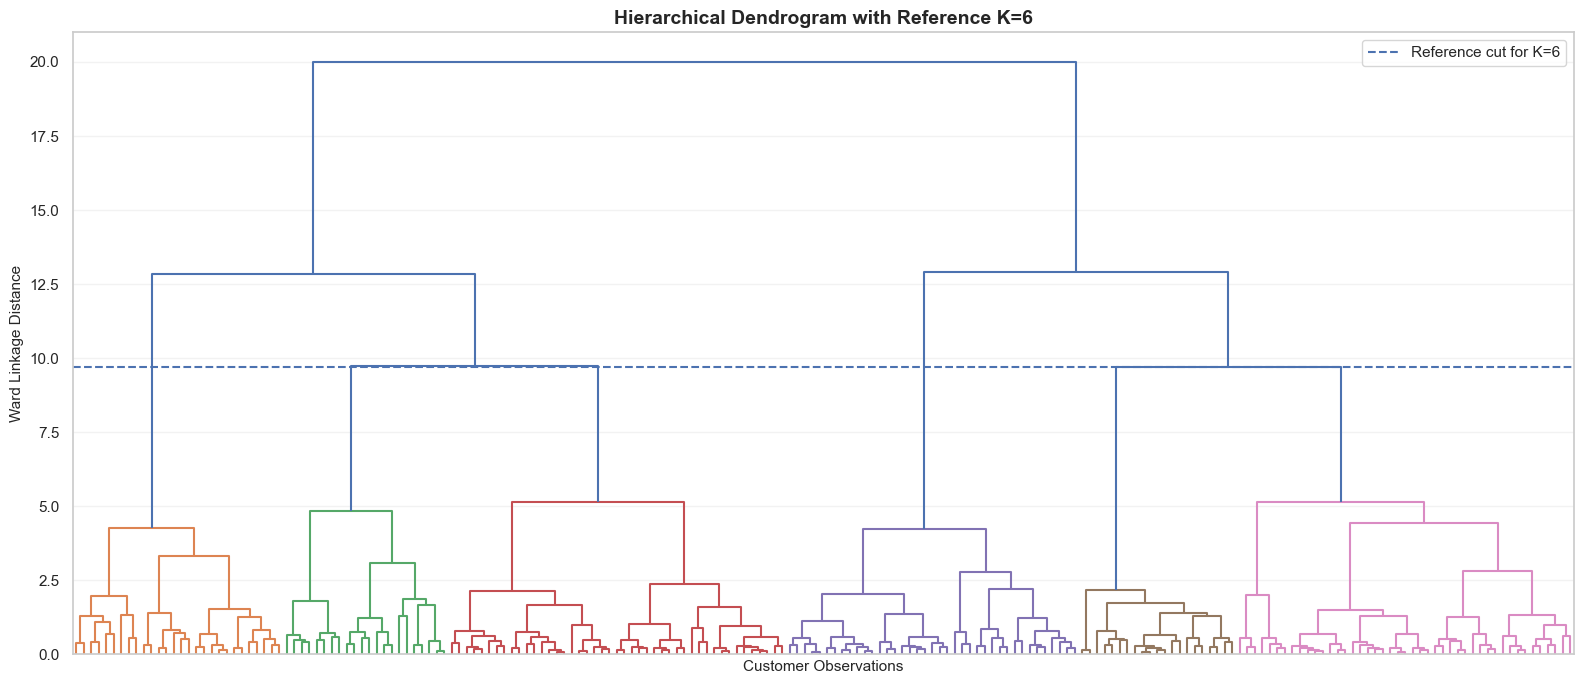


DENDROGRAM INTERPRETATION
---------------------------------------------------------------------------
The dendrogram illustrates the sequence in which customer groups are merged under Ward's hierarchical procedure.
The reference cut is used to visually examine the hierarchical structure around the cluster count identified during K-Means analysis.
The dendrogram is treated as structural evidence; final cluster quality will be assessed using quantitative metrics.


4.3 AGGLOMERATIVE CLUSTERING MODEL

MODEL DEVELOPMENT
---------------------------------------------------------------------------
Algorithm              : Agglomerative Hierarchical Clustering
Linkage                : Ward
Distance metric        : Euclidean
Number of clusters     : 6
Observations           : 200

HIERARCHICAL MODEL METRICS
---------------------------------------------------------------------------
Silhouette Score        : 0.4201
Davies-Bouldin Index    : 0.8521
Calinski-Harabasz Index : 127.99

✓ Agglomerati

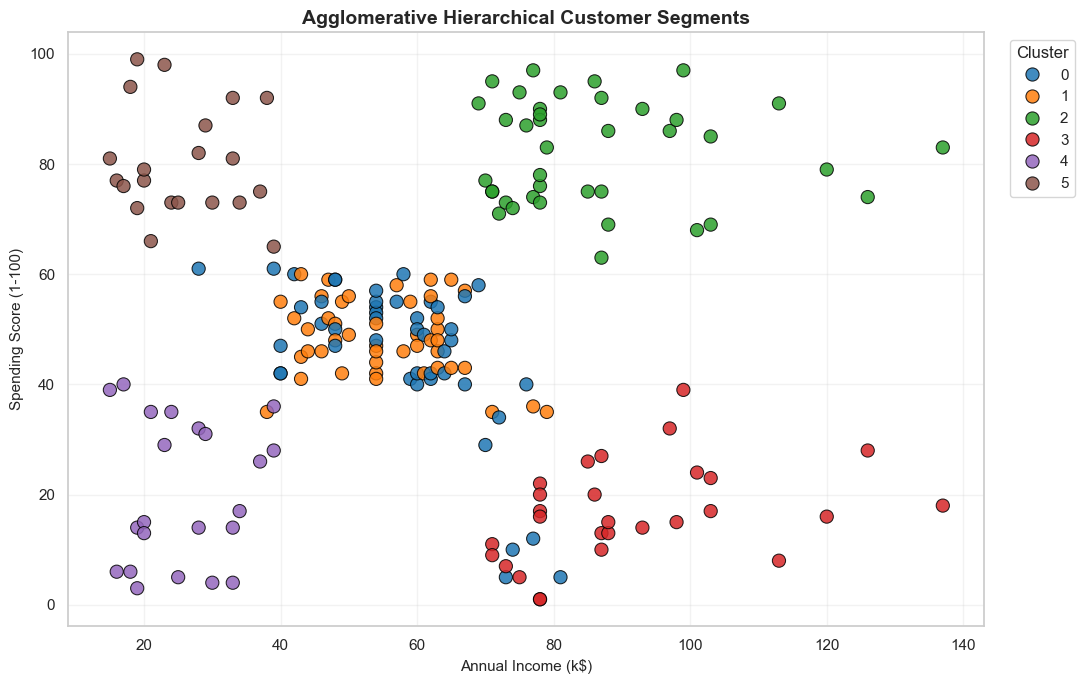

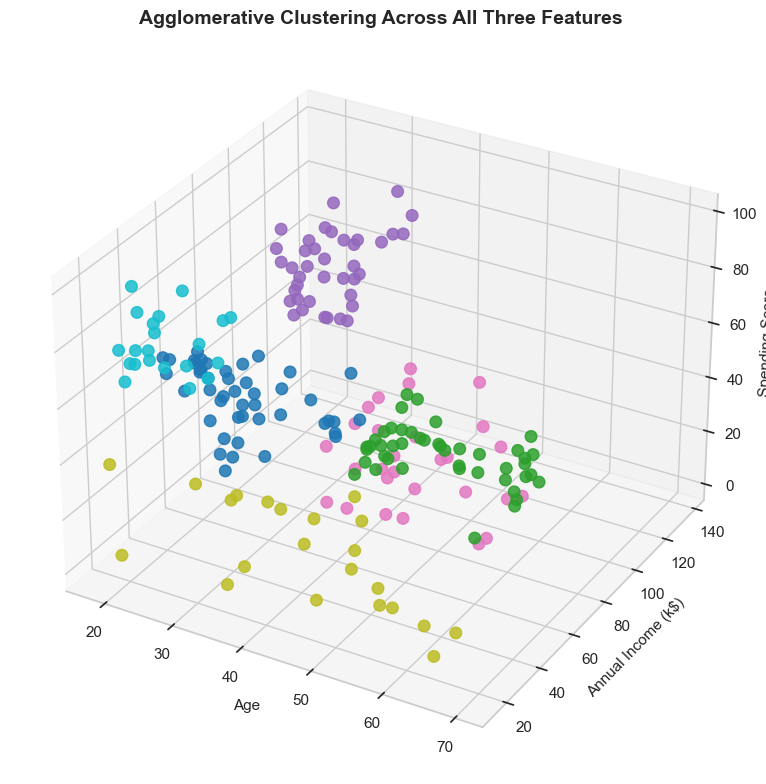



4.5 HIERARCHICAL CLUSTER PROFILING

ANALYTICAL PURPOSE
---------------------------------------------------------------------------
Describe the behavioural characteristics of each hierarchical customer segment using the original feature units.

HIERARCHICAL CUSTOMER SEGMENT PROFILE
---------------------------------------------------------------------------


Age                      Annual_Income                       Spending_Score                     
        count  mean median min max         count  mean median min  max          count  mean median min max
Cluster                                                                                                   
0          45 27.38  26.00  18  45            45 57.51  60.00  28   81             45 45.84  50.00   5  61
1          45 56.40  54.00  43  70            45 55.29  54.00  38   79             45 48.36  48.00  35  60
2          39 32.69  32.00  27  40            39 86.54  79.00  69  137             39 82.13  83.00  63  97
3          28 43.89  43.50  32  59            28 91.29  87.00  71  137             28 16.68  16.00   1  39
4          22 44.32  45.50  19  67            22 25.77  24.50  15   39             22 20.27  16.00   3  40
5          21 24.81  23.00  18  35            21 25.62  24.00  15   39             21 80.24  77.00  65  99


HIERARCHICAL BUSINESS-READY CLUSTER SUMMARY
---------------------------------------------------------------------------


,Cluster,Customer_Count,Average_Age,Average_Annual_Income,Average_Spending_Score,Customer_Percentage
0,0,45,27.38,57.51,45.84,22.50%
1,1,45,56.40,55.29,48.36,22.50%
2,2,39,32.69,86.54,82.13,19.50%
3,3,28,43.89,91.29,16.68,14.00%
4,4,22,44.32,25.77,20.27,11.00%
5,5,21,24.81,25.62,80.24,10.50%



GENDER DISTRIBUTION WITHIN HIERARCHICAL CLUSTERS
---------------------------------------------------------------------------
Note: Gender is used only for descriptive profiling and was not included in the clustering feature space.


Gender,Female,Male
Cluster,,
0,60.00,40.00
1,53.33,46.67
2,53.85,46.15
3,50.00,50.00
4,59.09,40.91
5,61.90,38.10




4.6 HIERARCHICAL CLUSTER SIZE VALIDATION

ANALYTICAL PURPOSE
---------------------------------------------------------------------------
Assess the distribution of observations across hierarchical customer segments.

HIERARCHICAL CLUSTER SIZE DISTRIBUTION
---------------------------------------------------------------------------


,Cluster,Customer_Count,Customer_Percentage
0,0,45,22.50%
1,1,45,22.50%
2,2,39,19.50%
3,3,28,14.00%
4,4,22,11.00%
5,5,21,10.50%


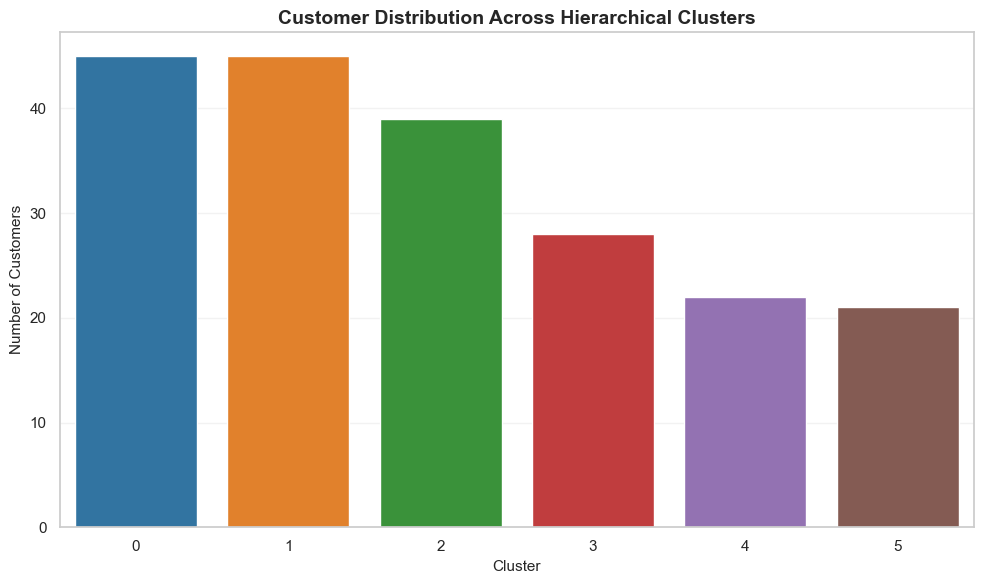



STEP 4 DECISION GATE

EVIDENCE
---------------------------------------------------------------------------
✓ Agglomerative Hierarchical Clustering was applied.
✓ The same standardized feature space X_scaled was used.
✓ The K-Means reference cluster count K=6 was retained.
✓ Ward linkage was used to build the hierarchical structure.
✓ A dendrogram was generated to inspect the merge structure.
✓ Customer segments were visualized.
✓ Hierarchical cluster profiles were generated.
✓ Cluster sizes were validated.
✓ Quantitative clustering metrics were calculated.

HIERARCHICAL MODEL QUALITY
---------------------------------------------------------------------------
Silhouette Score        : 0.4201
Davies-Bouldin Index    : 0.8521
Calinski-Harabasz Index : 127.99

ANALYTICAL DECISION
---------------------------------------------------------------------------
The hierarchical segmentation provides an alternative partition of the same standardized customer feature space.
It will not be declare

In [10]:
# ============================================================
# STEP 4 : AGGLOMERATIVE HIERARCHICAL CLUSTERING
# ============================================================
#
# Analytical Objective:
# Investigate whether Agglomerative Hierarchical Clustering
# identifies a comparable customer structure to the K-Means
# segmentation developed in Step 3.
#
# Methodological Principle:
# The same standardized feature space (X_scaled) established
# in Step 2 will be used to maintain a fair comparison.
#
# The cluster count identified in Step 3 will be used as the
# reference cluster count for the Agglomerative model.
# ============================================================


# ============================================================
# 4.1 HIERARCHICAL CLUSTERING STRATEGY
# ============================================================

print("=" * 75)
print("4.1 HIERARCHICAL CLUSTERING STRATEGY")
print("=" * 75)

print("\nANALYTICAL OBJECTIVE")
print("-" * 75)
print(
    "Investigate whether a hierarchical clustering approach identifies "
    "a comparable customer structure to the K-Means segmentation."
)

print("\nREFERENCE FEATURE SPACE")
print("-" * 75)

print(f"Number of observations : {X_scaled.shape[0]}")
print(f"Number of features    : {X_scaled.shape[1]}")
print(f"Features               : {clustering_features}")

print("\nMODELLING MATRIX")
print("-" * 75)
print("Primary matrix         : X_scaled")
print("Original matrix        : X")
print("Standardization        : StandardScaler")
print(f"Reference K from Step 3: {optimal_k}")

print("\nHIERARCHICAL CLUSTERING CONFIGURATION")
print("-" * 75)
print("Algorithm              : Agglomerative Hierarchical Clustering")
print("Linkage method         : Ward")
print("Distance metric        : Euclidean")
print(f"Number of clusters     : {optimal_k}")

print("\nMETHODOLOGICAL DECISION")
print("-" * 75)
print("✓ The same standardized feature space is retained.")
print("✓ The K-Means-selected cluster count is used as the reference.")
print("✓ Ward linkage is used to construct compact hierarchical groups.")
print(
    "✓ The resulting segmentation will be evaluated using the same "
    "clustering-quality metrics in Step 6."
)


# ============================================================
# 4.2 DENDROGRAM-BASED CLUSTER STRUCTURE
# ============================================================

print("\n\n" + "=" * 75)
print("4.2 DENDROGRAM-BASED CLUSTER STRUCTURE")
print("=" * 75)

print("\nANALYTICAL PURPOSE")
print("-" * 75)
print(
    "Visualize the hierarchical structure of customer observations "
    "and examine how clusters progressively merge as linkage distance increases."
)

# ------------------------------------------------------------
# Generate hierarchical linkage matrix using Ward's method.
# ------------------------------------------------------------

hierarchical_linkage = linkage(
    X_scaled,
    method="ward",
    metric="euclidean"
)

print("\nLINKAGE STRUCTURE")
print("-" * 75)

print(f"Number of observations : {X_scaled.shape[0]}")
print("Linkage method         : Ward")
print("Distance metric        : Euclidean")
print(f"Linkage matrix shape   : {hierarchical_linkage.shape}")

# ------------------------------------------------------------
# Full dendrogram
# ------------------------------------------------------------

plt.figure(figsize=(16, 7))

dendrogram(
    hierarchical_linkage,
    no_labels=True,
    color_threshold=None
)

plt.title(
    "Hierarchical Clustering Dendrogram",
    fontweight="bold"
)

plt.xlabel("Customer Observations")
plt.ylabel("Ward Linkage Distance")

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Reference dendrogram cut
# ------------------------------------------------------------

cut_heights = hierarchical_linkage[:, 2]

cut_index = len(cut_heights) - (optimal_k - 1)

if 0 <= cut_index < len(cut_heights):
    reference_cut_height = cut_heights[cut_index]
else:
    reference_cut_height = None

plt.figure(figsize=(16, 7))

dendrogram(
    hierarchical_linkage,
    no_labels=True,
    color_threshold=(
        reference_cut_height
        if reference_cut_height is not None
        else 0
    )
)

if reference_cut_height is not None:
    plt.axhline(
        reference_cut_height,
        linestyle="--",
        linewidth=1.5,
        label=f"Reference cut for K={optimal_k}"
    )

plt.title(
    f"Hierarchical Dendrogram with Reference K={optimal_k}",
    fontweight="bold"
)

plt.xlabel("Customer Observations")
plt.ylabel("Ward Linkage Distance")

if reference_cut_height is not None:
    plt.legend()

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print("\nDENDROGRAM INTERPRETATION")
print("-" * 75)

print(
    "The dendrogram illustrates the sequence in which customer groups "
    "are merged under Ward's hierarchical procedure."
)

print(
    "The reference cut is used to visually examine the hierarchical "
    "structure around the cluster count identified during K-Means analysis."
)

print(
    "The dendrogram is treated as structural evidence; final cluster "
    "quality will be assessed using quantitative metrics."
)


# ============================================================
# 4.3 AGGLOMERATIVE CLUSTERING MODEL
# ============================================================

print("\n\n" + "=" * 75)
print("4.3 AGGLOMERATIVE CLUSTERING MODEL")
print("=" * 75)

print("\nMODEL DEVELOPMENT")
print("-" * 75)

# ------------------------------------------------------------
# Build Agglomerative Clustering model.
# ------------------------------------------------------------

hierarchical_model = AgglomerativeClustering(
    n_clusters=optimal_k,
    metric="euclidean",
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(
    X_scaled
)

# ------------------------------------------------------------
# Store original customer attributes with cluster labels.
# ------------------------------------------------------------

hierarchical_clustered_data = X.copy()

hierarchical_clustered_data["Cluster"] = hierarchical_labels

# ------------------------------------------------------------
# Calculate clustering-quality metrics.
# These metrics will also contribute to Step 6 comparison.
# ------------------------------------------------------------

hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

hierarchical_db = davies_bouldin_score(
    X_scaled,
    hierarchical_labels
)

hierarchical_ch = calinski_harabasz_score(
    X_scaled,
    hierarchical_labels
)

print("Algorithm              : Agglomerative Hierarchical Clustering")
print("Linkage                : Ward")
print("Distance metric        : Euclidean")
print(f"Number of clusters     : {optimal_k}")
print(f"Observations           : {X_scaled.shape[0]}")

print("\nHIERARCHICAL MODEL METRICS")
print("-" * 75)

print(f"Silhouette Score        : {hierarchical_silhouette:.4f}")
print(f"Davies-Bouldin Index    : {hierarchical_db:.4f}")
print(f"Calinski-Harabasz Index : {hierarchical_ch:.2f}")

print("\n✓ Agglomerative model fitted successfully.")
print("✓ Cluster labels generated for all observations.")


# ============================================================
# 4.4 HIERARCHICAL CLUSTER VISUALIZATION
# ============================================================

print("\n\n" + "=" * 75)
print("4.4 HIERARCHICAL CLUSTER VISUALIZATION")
print("=" * 75)

print("\nVISUALIZATION PURPOSE")
print("-" * 75)

print(
    "Visualize the hierarchical customer segmentation using the same "
    "business-oriented feature space used for K-Means visualization."
)

# ------------------------------------------------------------
# 2D business-oriented visualization
# ------------------------------------------------------------

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=hierarchical_clustered_data,
    x="Annual_Income",
    y="Spending_Score",
    hue="Cluster",
    palette="tab10",
    s=90,
    alpha=0.85,
    edgecolor="black"
)

plt.title(
    "Agglomerative Hierarchical Customer Segments",
    fontweight="bold"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3D visualization using all three clustering variables
# ------------------------------------------------------------

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    hierarchical_clustered_data["Age"],
    hierarchical_clustered_data["Annual_Income"],
    hierarchical_clustered_data["Spending_Score"],
    c=hierarchical_clustered_data["Cluster"],
    cmap="tab10",
    s=70,
    alpha=0.85
)

ax.set_title(
    "Agglomerative Clustering Across All Three Features",
    fontweight="bold"
)

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score")

plt.tight_layout()
plt.show()


# ============================================================
# 4.5 HIERARCHICAL CLUSTER PROFILING
# ============================================================

print("\n\n" + "=" * 75)
print("4.5 HIERARCHICAL CLUSTER PROFILING")
print("=" * 75)

print("\nANALYTICAL PURPOSE")
print("-" * 75)

print(
    "Describe the behavioural characteristics of each hierarchical "
    "customer segment using the original feature units."
)

# ------------------------------------------------------------
# Detailed cluster profile
# ------------------------------------------------------------

hierarchical_profile = (
    hierarchical_clustered_data
    .groupby("Cluster")[clustering_features]
    .agg(["count", "mean", "median", "min", "max"])
)

print("\nHIERARCHICAL CUSTOMER SEGMENT PROFILE")
print("-" * 75)

display(
    hierarchical_profile.round(2)
)


# ------------------------------------------------------------
# Business-readable cluster summary
# ------------------------------------------------------------

hierarchical_summary = (
    hierarchical_clustered_data
    .groupby("Cluster")
    .agg(
        Customer_Count=("Cluster", "size"),
        Average_Age=("Age", "mean"),
        Average_Annual_Income=("Annual_Income", "mean"),
        Average_Spending_Score=("Spending_Score", "mean")
    )
    .reset_index()
)

hierarchical_summary["Customer_Percentage"] = (
    hierarchical_summary["Customer_Count"]
    / len(hierarchical_clustered_data)
    * 100
)

print("\nHIERARCHICAL BUSINESS-READY CLUSTER SUMMARY")
print("-" * 75)

display(
    hierarchical_summary.style.format({
        "Average_Age": "{:.2f}",
        "Average_Annual_Income": "{:.2f}",
        "Average_Spending_Score": "{:.2f}",
        "Customer_Percentage": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# Gender profiling
# Gender is descriptive only and was not used for clustering.
# ------------------------------------------------------------

hierarchical_gender_profile = pd.crosstab(
    hierarchical_clustered_data["Cluster"],
    df_clean["Gender"],
    normalize="index"
) * 100

print("\nGENDER DISTRIBUTION WITHIN HIERARCHICAL CLUSTERS")
print("-" * 75)

print(
    "Note: Gender is used only for descriptive profiling and was not "
    "included in the clustering feature space."
)

display(
    hierarchical_gender_profile.round(2)
)


# ============================================================
# 4.6 HIERARCHICAL CLUSTER SIZE VALIDATION
# ============================================================

print("\n\n" + "=" * 75)
print("4.6 HIERARCHICAL CLUSTER SIZE VALIDATION")
print("=" * 75)

print("\nANALYTICAL PURPOSE")
print("-" * 75)

print(
    "Assess the distribution of observations across hierarchical "
    "customer segments."
)

hierarchical_cluster_sizes = (
    hierarchical_clustered_data["Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

hierarchical_cluster_sizes.columns = [
    "Cluster",
    "Customer_Count"
]

hierarchical_cluster_sizes["Customer_Percentage"] = (
    hierarchical_cluster_sizes["Customer_Count"]
    / len(hierarchical_clustered_data)
    * 100
)

print("\nHIERARCHICAL CLUSTER SIZE DISTRIBUTION")
print("-" * 75)

display(
    hierarchical_cluster_sizes.style.format({
        "Customer_Percentage": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# Cluster-size visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=hierarchical_cluster_sizes,
    x="Cluster",
    y="Customer_Count",
    hue="Cluster",
    palette="tab10",
    legend=False
)

plt.title(
    "Customer Distribution Across Hierarchical Clusters",
    fontweight="bold"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


# ============================================================
# STEP 4 DECISION GATE
# ============================================================

print("\n\n" + "=" * 75)
print("STEP 4 DECISION GATE")
print("=" * 75)

print("\nEVIDENCE")
print("-" * 75)

print("✓ Agglomerative Hierarchical Clustering was applied.")
print("✓ The same standardized feature space X_scaled was used.")
print(f"✓ The K-Means reference cluster count K={optimal_k} was retained.")
print("✓ Ward linkage was used to build the hierarchical structure.")
print("✓ A dendrogram was generated to inspect the merge structure.")
print("✓ Customer segments were visualized.")
print("✓ Hierarchical cluster profiles were generated.")
print("✓ Cluster sizes were validated.")
print("✓ Quantitative clustering metrics were calculated.")

print("\nHIERARCHICAL MODEL QUALITY")
print("-" * 75)

print(f"Silhouette Score        : {hierarchical_silhouette:.4f}")
print(f"Davies-Bouldin Index    : {hierarchical_db:.4f}")
print(f"Calinski-Harabasz Index : {hierarchical_ch:.2f}")

print("\nANALYTICAL DECISION")
print("-" * 75)

print(
    "The hierarchical segmentation provides an alternative partition "
    "of the same standardized customer feature space."
)

print(
    "It will not be declared superior to K-Means at this stage."
)

print(
    "Both algorithms will be compared systematically in Step 6 using "
    "the same evaluation metrics and cluster-size evidence."
)

print("\nNEXT ANALYTICAL QUESTION")
print("-" * 75)

print(
    "Can a density-based method identify customer groups or unusual "
    "observations that centroid-based and hierarchical methods may not capture?"
)

print(
    "\nThis question will be investigated in Step 5 using DBSCAN."
)


# ============================================================
# STEP 4 ANALYTICAL CONCLUSION
# ============================================================

print("\n\n" + "=" * 75)
print("STEP 4 ANALYTICAL CONCLUSION")
print("=" * 75)

print("\nHIERARCHICAL ANALYSIS")
print("-" * 75)

print("✓ Agglomerative Hierarchical Clustering completed.")
print("✓ Ward linkage was applied to the standardized feature space.")
print(f"✓ Reference cluster count retained : {optimal_k}")
print("✓ Dendrogram structure examined.")
print("✓ Customer segments visualized.")
print("✓ Cluster profiles generated.")
print("✓ Cluster sizes examined.")

print("\nMODEL EVALUATION")
print("-" * 75)

print(f"✓ Silhouette Score        : {hierarchical_silhouette:.4f}")
print(f"✓ Davies-Bouldin Index    : {hierarchical_db:.4f}")
print(f"✓ Calinski-Harabasz Index : {hierarchical_ch:.2f}")

print("\nMODELLING CONSISTENCY")
print("-" * 75)

print("✓ X_scaled remains the common modelling matrix.")
print("✓ X remains the original interpretation matrix.")
print("✓ No additional feature transformation was introduced.")

print("\nANALYTICAL TRANSITION")
print("-" * 75)

print(
    "Step 3 established a K-Means segmentation using the strongest "
    "candidate cluster count identified during K-Means analysis."
)

print(
    "Step 4 investigated whether a hierarchical approach can produce "
    "a comparable segmentation using the same customer feature space."
)

print(
    "Step 5 will introduce DBSCAN to investigate density-based "
    "structure and potential noise observations."
)


# ============================================================
# STEP 4 COMPLETED
# ============================================================

print("\n\n" + "=" * 75)
print("STEP 4 COMPLETED : HIERARCHICAL SEGMENTATION")
print("=" * 75)

print("✓ Hierarchical Strategy Defined")
print("✓ Ward Linkage Applied")
print("✓ Dendrogram Generated")
print("✓ Reference Cluster Structure Examined")
print("✓ Agglomerative Model Developed")
print("✓ Customer Segments Visualized")
print("✓ Cluster Profiles Generated")
print("✓ Gender Descriptively Profiled")
print("✓ Cluster Sizes Validated")
print("✓ Quantitative Metrics Calculated")
print("✓ Decision Gate Completed")
print("✓ Analytical Conclusion Completed")

print("\nREADY FOR STEP 5:")
print("DBSCAN CLUSTERING & DENSITY-BASED SEGMENTATION")

STEP 6 : CLUSTERING PERFORMANCE EVALUATION

ANALYTICAL OBJECTIVE
--------------------
Compare K-Means, Agglomerative Hierarchical Clustering and DBSCAN
using a common and reproducible evaluation framework.

The comparison considers:

• Silhouette Score
• Davies-Bouldin Index
• Calinski-Harabasz Index
• Number of clusters
• Cluster-size distribution
• Customer coverage
• DBSCAN noise percentage
• Cluster-size balance
• Structural and interpretability considerations

IMPORTANT METHODOLOGICAL NOTE
-----------------------------
K-Means and Agglomerative Clustering assign every customer
to a cluster.

DBSCAN can classify observations as noise (-1). Therefore,
DBSCAN internal metrics are calculated only on non-noise
observations and must be interpreted together with customer
coverage and noise percentage.

No single metric is used independently to determine the
overall clustering suitability.


6.1 EVALUATION FRAMEWORK

PURPOSE
-------
Establish a common and reproducible evaluation framework

,Algorithm,Silhouette
0,K-Means,0.4284
1,Agglomerative,0.4201
2,DBSCAN,0.5454


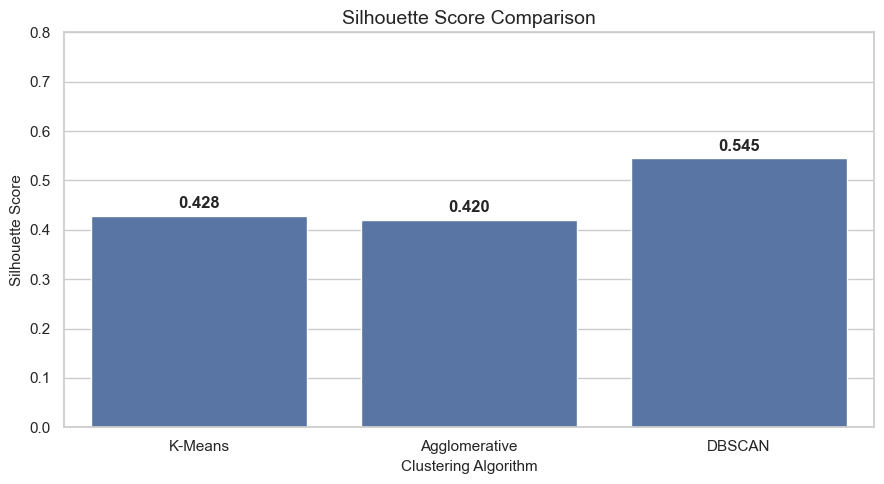


6.3 DAVIES-BOULDIN INDEX COMPARISON

ANALYTICAL PURPOSE
------------------
The Davies-Bouldin Index evaluates the similarity between
clusters using within-cluster dispersion and between-cluster
separation.

Interpretation:
• Lower values indicate better separation.
• Higher values indicate greater cluster similarity/overlap.

Preferred direction:
Lower is generally better.

DBSCAN NOTE
-----------
DBSCAN's Davies-Bouldin Index is calculated using
non-noise observations only.



,Algorithm,Davies_Bouldin
0,K-Means,0.8254
1,Agglomerative,0.8521
2,DBSCAN,0.6222


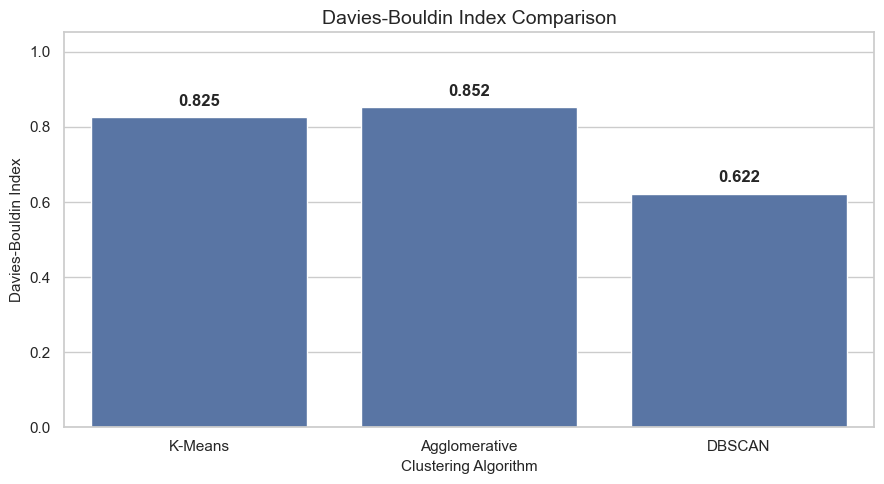


6.4 CALINSKI-HARABASZ INDEX COMPARISON

ANALYTICAL PURPOSE
------------------
The Calinski-Harabasz Index evaluates the ratio between
between-cluster dispersion and within-cluster dispersion.

Interpretation:
• Higher values generally indicate better-defined clusters.
• Lower values indicate weaker separation relative to
  within-cluster variation.

Preferred direction:
Higher is generally better.

DBSCAN NOTE
-----------
DBSCAN's Calinski-Harabasz Index is calculated using
non-noise observations only.



,Algorithm,Calinski_Harabasz
0,K-Means,135.10
1,Agglomerative,127.99
2,DBSCAN,176.91


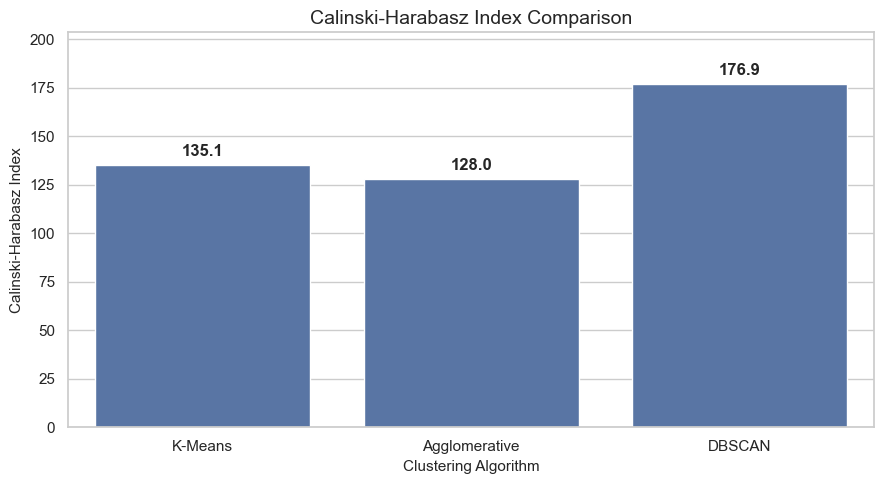


6.5 CLUSTER SIZE & CUSTOMER COVERAGE VALIDATION

ANALYTICAL PURPOSE
------------------
Internal metrics alone do not describe the complete structure
of a customer segmentation.

Therefore, cluster sizes and customer coverage are examined.

For K-Means and Agglomerative Clustering:
• Every customer is assigned to a cluster.

For DBSCAN:
• Some observations may be classified as noise (-1).
• Noise is not automatically considered an error or outlier.
• It represents observations that do not satisfy the selected
  local density requirements.


K-MEANS CLUSTER SIZE DISTRIBUTION
-------------------------------------------------------


,Cluster,Customer_Count,Percentage
0,0,45,22.50%
1,1,39,19.50%
2,2,33,16.50%
3,3,39,19.50%
4,4,23,11.50%
5,5,21,10.50%



AGGLOMERATIVE CLUSTER SIZE DISTRIBUTION
-------------------------------------------------------


,Cluster,Customer_Count,Percentage
0,0,45,22.50%
1,1,45,22.50%
2,2,39,19.50%
3,3,28,14.00%
4,4,22,11.00%
5,5,21,10.50%



DBSCAN CLUSTER AND NOISE DISTRIBUTION
-------------------------------------------------------


,Cluster_Label,Customer_Count,Percentage
0,Noise,73,36.50%
1,Cluster 0,19,9.50%
2,Cluster 1,48,24.00%
3,Cluster 2,29,14.50%
4,Cluster 3,31,15.50%



CLUSTER-SIZE BALANCE ANALYSIS
-------------------------------------------------------


,Algorithm,Minimum_Cluster_Size,Maximum_Cluster_Size,Mean_Cluster_Size,Cluster_Size_CV_Percentage
0,K-Means,21,45,33.33,26.25%
1,Agglomerative,21,45,33.33,30.33%
2,DBSCAN,19,48,31.75,32.84%



INTERPRETATION NOTE
-------------------
Cluster-size balance is treated as descriptive structural
evidence rather than as a standalone optimisation metric.

A cluster solution may contain unequal groups because genuine
customer populations do not necessarily have equal sizes.
Therefore, unequal cluster sizes are not automatically treated
as a modelling problem.


CUSTOMER COVERAGE COMPARISON
-------------------------------------------------------


,Algorithm,Clustered_Customers,Coverage_Percentage,Noise_Count,Noise_Percentage
0,K-Means,200,100.00%,0,0.00%
1,Agglomerative,200,100.00%,0,0.00%
2,DBSCAN,127,63.50%,73,36.50%


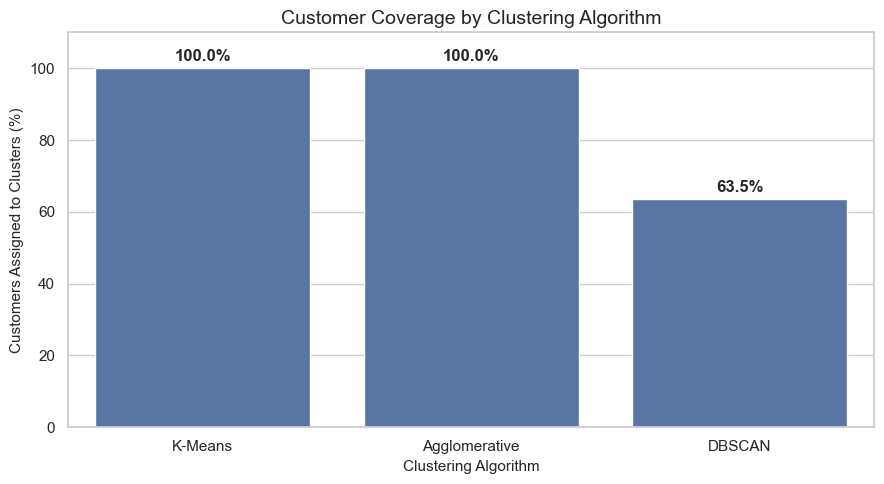


DBSCAN NOISE ANALYSIS
-------------------------------------------------------
Clustered customers : 127
Noise observations  : 73
Coverage            : 63.50%
Noise percentage    : 36.50%


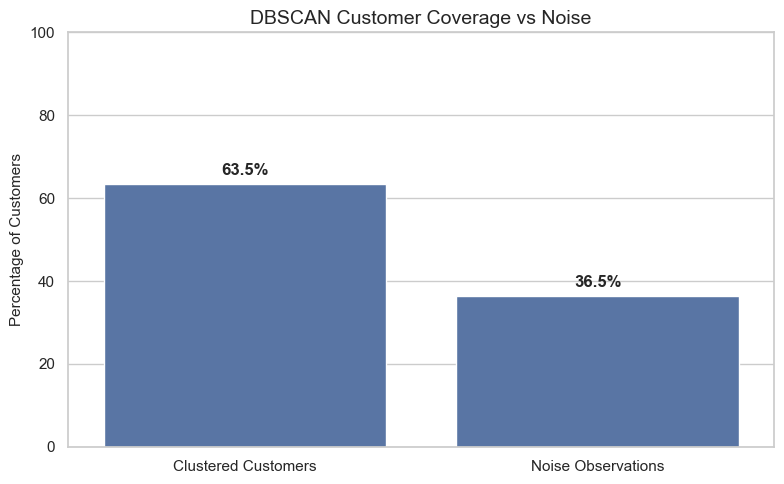


6.6 OVERALL ALGORITHM COMPARISON

FINAL COMPARISON FRAMEWORK
--------------------------
The three clustering approaches are compared using:

1. Internal clustering quality
2. Number of clusters
3. Customer coverage
4. Noise percentage
5. Cluster-size structure
6. Cluster-size balance

METRIC DIRECTION
---------------
Silhouette Score:
Higher is generally better.

Davies-Bouldin Index:
Lower is generally better.

Calinski-Harabasz Index:
Higher is generally better.

Coverage:
Higher coverage means a larger proportion of customers
receives a cluster assignment.

Noise:
Relevant specifically to DBSCAN and must be interpreted
within the context of density-based clustering.

CLUSTER-SIZE BALANCE:
Used as descriptive structural evidence rather than as an
independent optimisation criterion.

IMPORTANT
---------
The comparison does not declare an algorithm superior based
on a single metric.

DBSCAN metrics are calculated on non-noise observations.
Therefore, they are interpreted together with

,Algorithm,Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz,Clustered_Customers,Coverage_Percentage,Noise_Percentage
0,K-Means,6,0.4284,0.8254,135.10,200,100.00%,0.00%
1,Agglomerative,6,0.4201,0.8521,127.99,200,100.00%,0.00%
2,DBSCAN,4,0.5454,0.6222,176.91,127,63.50%,36.50%



METRIC INTERPRETATION GUIDE
-------------------------------------------------------


,Metric,Preferred Direction,Analytical Purpose
0,Silhouette Score,Higher,Measures cluster cohesion and separation
1,Davies-Bouldin Index,Lower,Measures cluster similarity and separation
2,Calinski-Harabasz Index,Higher,Measures between-cluster versus within-cluster...
3,Customer Coverage,"Higher, subject to interpretability",Measures proportion of customers receiving clu...
4,Noise Percentage,"Lower, subject to density structure",Measures observations not assigned to DBSCAN c...
5,Cluster-Size Balance,Descriptive only,Describes whether cluster sizes are highly uneven



MODEL-SPECIFIC STRUCTURAL SUMMARY

K-Means
--------------------------------------------------
Number of clusters       : 6
Silhouette Score         : 0.4284
Davies-Bouldin Index     : 0.8254
Calinski-Harabasz Index  : 135.10
Clustered customers      : 200
Customer coverage        : 100.00%
Noise percentage         : 0.00%

Agglomerative
--------------------------------------------------
Number of clusters       : 6
Silhouette Score         : 0.4201
Davies-Bouldin Index     : 0.8521
Calinski-Harabasz Index  : 127.99
Clustered customers      : 200
Customer coverage        : 100.00%
Noise percentage         : 0.00%

DBSCAN
--------------------------------------------------
Number of clusters       : 4
Silhouette Score         : 0.5454
Davies-Bouldin Index     : 0.6222
Calinski-Harabasz Index  : 176.91
Clustered customers      : 127
Customer coverage        : 63.50%
Noise percentage         : 36.50%

STEP 6 DECISION GATE

EVIDENCE CHECK
--------------

✓ K-Means evaluation completed.
✓ Ag

In [14]:
# ============================================================
# STEP 6 : CLUSTERING PERFORMANCE EVALUATION
# MALL CUSTOMER SEGMENTATION - UNSUPERVISED LEARNING PR-1
# ============================================================

print("=" * 75)
print("STEP 6 : CLUSTERING PERFORMANCE EVALUATION")
print("=" * 75)

print("""
ANALYTICAL OBJECTIVE
--------------------
Compare K-Means, Agglomerative Hierarchical Clustering and DBSCAN
using a common and reproducible evaluation framework.

The comparison considers:

• Silhouette Score
• Davies-Bouldin Index
• Calinski-Harabasz Index
• Number of clusters
• Cluster-size distribution
• Customer coverage
• DBSCAN noise percentage
• Cluster-size balance
• Structural and interpretability considerations

IMPORTANT METHODOLOGICAL NOTE
-----------------------------
K-Means and Agglomerative Clustering assign every customer
to a cluster.

DBSCAN can classify observations as noise (-1). Therefore,
DBSCAN internal metrics are calculated only on non-noise
observations and must be interpreted together with customer
coverage and noise percentage.

No single metric is used independently to determine the
overall clustering suitability.
""")


# ============================================================
# 6.1 EVALUATION FRAMEWORK
# ============================================================

print("\n" + "=" * 75)
print("6.1 EVALUATION FRAMEWORK")
print("=" * 75)

print("""
PURPOSE
-------
Establish a common and reproducible evaluation framework for
the three clustering algorithms developed in Steps 3, 4 and 5.

COMMON MODELLING SPACE
----------------------
All three algorithms are evaluated using the standardized
feature matrix X_scaled created in Step 2.

Algorithms:
1. K-Means
2. Agglomerative Hierarchical Clustering
3. DBSCAN

Evaluation Metrics:
1. Silhouette Score
2. Davies-Bouldin Index
3. Calinski-Harabasz Index

Additional Structural Evidence:
• Number of clusters
• Cluster-size distribution
• Customer coverage
• Noise percentage
• Cluster-size balance
""")


# ============================================================
# REQUIRED VARIABLE VALIDATION
# ============================================================

required_variables = [
    "X_scaled",
    "kmeans_labels",
    "hierarchical_labels",
    "dbscan_labels"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:

    raise NameError(
        "The following required variables are missing: "
        + ", ".join(missing_variables)
        + ". Please run Steps 2-5 before executing Step 6."
    )

print("✓ Required clustering outputs are available.")


# ============================================================
# FEATURE NAME RECOVERY
# ============================================================

# The previous version depended on feature_names being created
# somewhere earlier. This version safely recovers the names.

if "feature_names" not in globals():

    if "X" in globals() and hasattr(X, "columns"):

        feature_names = X.columns.tolist()

    else:

        feature_names = [
            "Age",
            "Annual_Income",
            "Spending_Score"
        ]

print("\nREFERENCE DATA")
print("-" * 55)

print(
    f"Total customers                : "
    f"{len(X_scaled)}"
)

print(
    f"Number of clustering features : "
    f"{X_scaled.shape[1]}"
)

print(
    f"Feature space                  : "
    f"{feature_names}"
)

print("Standardization                : StandardScaler")
print("Evaluation matrix              : X_scaled")


# ============================================================
# LABEL VALIDATION
# ============================================================

kmeans_labels = np.asarray(kmeans_labels)
hierarchical_labels = np.asarray(hierarchical_labels)
dbscan_labels = np.asarray(dbscan_labels)

label_lengths = {
    "X_scaled": len(X_scaled),
    "K-Means labels": len(kmeans_labels),
    "Agglomerative labels": len(hierarchical_labels),
    "DBSCAN labels": len(dbscan_labels)
}

print("\nLABEL VALIDATION")
print("-" * 55)

for name, length in label_lengths.items():

    print(
        f"{name:<25}: {length} observations"
    )

if len(kmeans_labels) != len(X_scaled):
    raise ValueError(
        "K-Means labels do not match X_scaled observations."
    )

if len(hierarchical_labels) != len(X_scaled):
    raise ValueError(
        "Agglomerative labels do not match X_scaled observations."
    )

if len(dbscan_labels) != len(X_scaled):
    raise ValueError(
        "DBSCAN labels do not match X_scaled observations."
    )

print("✓ All clustering labels match the 200-observation dataset.")


# ============================================================
# COMMON EVALUATION FUNCTION
# ============================================================

def evaluate_clustering_solution(
    algorithm_name,
    X_data,
    labels,
    exclude_noise=False
):
    """
    Calculate common clustering evaluation metrics.

    Parameters
    ----------
    algorithm_name : str
        Name of clustering algorithm.

    X_data : array-like
        Feature matrix used for clustering.

    labels : array-like
        Cluster labels.

    exclude_noise : bool
        If True, DBSCAN noise (-1) is excluded from
        internal metric calculations.
    """

    labels = np.asarray(labels)

    # --------------------------------------------------------
    # Determine observations used for metric calculation
    # --------------------------------------------------------

    if exclude_noise:

        valid_mask = labels != -1

    else:

        valid_mask = np.ones(
            len(labels),
            dtype=bool
        )

    X_evaluation = X_data[valid_mask]
    labels_evaluation = labels[valid_mask]

    # --------------------------------------------------------
    # Cluster information
    # --------------------------------------------------------

    unique_clusters = np.unique(
        labels_evaluation
    )

    number_of_clusters = len(
        unique_clusters
    )

    # --------------------------------------------------------
    # Internal clustering metrics
    # --------------------------------------------------------

    if number_of_clusters >= 2:

        silhouette = silhouette_score(
            X_evaluation,
            labels_evaluation
        )

        davies_bouldin = davies_bouldin_score(
            X_evaluation,
            labels_evaluation
        )

        calinski_harabasz = calinski_harabasz_score(
            X_evaluation,
            labels_evaluation
        )

    else:

        silhouette = np.nan
        davies_bouldin = np.nan
        calinski_harabasz = np.nan

    # --------------------------------------------------------
    # Coverage and noise
    # --------------------------------------------------------

    clustered_customers = int(
        valid_mask.sum()
    )

    noise_count = int(
        len(labels) - clustered_customers
    )

    coverage_percentage = (
        clustered_customers
        / len(labels)
    ) * 100

    noise_percentage = (
        noise_count
        / len(labels)
    ) * 100

    return {
        "Algorithm": algorithm_name,
        "Clusters": number_of_clusters,
        "Silhouette": silhouette,
        "Davies_Bouldin": davies_bouldin,
        "Calinski_Harabasz": calinski_harabasz,
        "Clustered_Customers": clustered_customers,
        "Coverage_Percentage": coverage_percentage,
        "Noise_Count": noise_count,
        "Noise_Percentage": noise_percentage
    }


# ============================================================
# GENERATE COMMON EVALUATION RESULTS
# ============================================================

evaluation_results = [

    evaluate_clustering_solution(
        algorithm_name="K-Means",
        X_data=X_scaled,
        labels=kmeans_labels,
        exclude_noise=False
    ),

    evaluate_clustering_solution(
        algorithm_name="Agglomerative",
        X_data=X_scaled,
        labels=hierarchical_labels,
        exclude_noise=False
    ),

    evaluate_clustering_solution(
        algorithm_name="DBSCAN",
        X_data=X_scaled,
        labels=dbscan_labels,
        exclude_noise=True
    )
]

evaluation_df = pd.DataFrame(
    evaluation_results
)


# ============================================================
# 6.2 SILHOUETTE SCORE COMPARISON
# ============================================================

print("\n" + "=" * 75)
print("6.2 SILHOUETTE SCORE COMPARISON")
print("=" * 75)

print("""
ANALYTICAL PURPOSE
------------------
The Silhouette Score measures how similar each observation is
to its own cluster compared with other clusters.

Interpretation:
• Higher values generally indicate stronger cohesion and separation.
• Values near zero indicate overlapping cluster boundaries.
• Negative values may indicate poorly assigned observations.

Preferred direction:
Higher is generally better.

DBSCAN NOTE
-----------
DBSCAN's Silhouette Score is calculated using non-noise
observations only.
""")

silhouette_table = evaluation_df[
    [
        "Algorithm",
        "Silhouette"
    ]
].copy()

display(
    silhouette_table.style.format({
        "Silhouette": "{:.4f}"
    })
)

# Visualization

plt.figure(
    figsize=(9, 5)
)

sns.barplot(
    data=silhouette_table,
    x="Algorithm",
    y="Silhouette"
)

plt.title(
    "Silhouette Score Comparison"
)

plt.xlabel(
    "Clustering Algorithm"
)

plt.ylabel(
    "Silhouette Score"
)

max_silhouette = (
    silhouette_table["Silhouette"].max()
)

plt.ylim(
    0,
    max(
        0.8,
        max_silhouette + 0.10
    )
)

for index, value in enumerate(
    silhouette_table["Silhouette"]
):

    plt.text(
        index,
        value + 0.015,
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 6.3 DAVIES-BOULDIN INDEX COMPARISON
# ============================================================

print("\n" + "=" * 75)
print("6.3 DAVIES-BOULDIN INDEX COMPARISON")
print("=" * 75)

print("""
ANALYTICAL PURPOSE
------------------
The Davies-Bouldin Index evaluates the similarity between
clusters using within-cluster dispersion and between-cluster
separation.

Interpretation:
• Lower values indicate better separation.
• Higher values indicate greater cluster similarity/overlap.

Preferred direction:
Lower is generally better.

DBSCAN NOTE
-----------
DBSCAN's Davies-Bouldin Index is calculated using
non-noise observations only.
""")

davies_table = evaluation_df[
    [
        "Algorithm",
        "Davies_Bouldin"
    ]
].copy()

display(
    davies_table.style.format({
        "Davies_Bouldin": "{:.4f}"
    })
)

plt.figure(
    figsize=(9, 5)
)

sns.barplot(
    data=davies_table,
    x="Algorithm",
    y="Davies_Bouldin"
)

plt.title(
    "Davies-Bouldin Index Comparison"
)

plt.xlabel(
    "Clustering Algorithm"
)

plt.ylabel(
    "Davies-Bouldin Index"
)

max_db = (
    davies_table["Davies_Bouldin"].max()
)

plt.ylim(
    0,
    max_db + 0.20
)

for index, value in enumerate(
    davies_table["Davies_Bouldin"]
):

    plt.text(
        index,
        value + 0.03,
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 6.4 CALINSKI-HARABASZ INDEX COMPARISON
# ============================================================

print("\n" + "=" * 75)
print("6.4 CALINSKI-HARABASZ INDEX COMPARISON")
print("=" * 75)

print("""
ANALYTICAL PURPOSE
------------------
The Calinski-Harabasz Index evaluates the ratio between
between-cluster dispersion and within-cluster dispersion.

Interpretation:
• Higher values generally indicate better-defined clusters.
• Lower values indicate weaker separation relative to
  within-cluster variation.

Preferred direction:
Higher is generally better.

DBSCAN NOTE
-----------
DBSCAN's Calinski-Harabasz Index is calculated using
non-noise observations only.
""")

calinski_table = evaluation_df[
    [
        "Algorithm",
        "Calinski_Harabasz"
    ]
].copy()

display(
    calinski_table.style.format({
        "Calinski_Harabasz": "{:.2f}"
    })
)

plt.figure(
    figsize=(9, 5)
)

sns.barplot(
    data=calinski_table,
    x="Algorithm",
    y="Calinski_Harabasz"
)

plt.title(
    "Calinski-Harabasz Index Comparison"
)

plt.xlabel(
    "Clustering Algorithm"
)

plt.ylabel(
    "Calinski-Harabasz Index"
)

max_ch = (
    calinski_table["Calinski_Harabasz"].max()
)

plt.ylim(
    0,
    max_ch * 1.15
)

for index, value in enumerate(
    calinski_table["Calinski_Harabasz"]
):

    plt.text(
        index,
        value + (max_ch * 0.025),
        f"{value:.1f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 6.5 CLUSTER SIZE & CUSTOMER COVERAGE VALIDATION
# ============================================================

print("\n" + "=" * 75)
print("6.5 CLUSTER SIZE & CUSTOMER COVERAGE VALIDATION")
print("=" * 75)

print("""
ANALYTICAL PURPOSE
------------------
Internal metrics alone do not describe the complete structure
of a customer segmentation.

Therefore, cluster sizes and customer coverage are examined.

For K-Means and Agglomerative Clustering:
• Every customer is assigned to a cluster.

For DBSCAN:
• Some observations may be classified as noise (-1).
• Noise is not automatically considered an error or outlier.
• It represents observations that do not satisfy the selected
  local density requirements.
""")


# ------------------------------------------------------------
# K-Means cluster sizes
# ------------------------------------------------------------

kmeans_sizes = (
    pd.Series(kmeans_labels)
    .value_counts()
    .sort_index()
    .reset_index()
)

kmeans_sizes.columns = [
    "Cluster",
    "Customer_Count"
]

kmeans_sizes["Percentage"] = (
    kmeans_sizes["Customer_Count"]
    / len(X_scaled)
) * 100


# ------------------------------------------------------------
# Agglomerative cluster sizes
# ------------------------------------------------------------

hierarchical_sizes = (
    pd.Series(hierarchical_labels)
    .value_counts()
    .sort_index()
    .reset_index()
)

hierarchical_sizes.columns = [
    "Cluster",
    "Customer_Count"
]

hierarchical_sizes["Percentage"] = (
    hierarchical_sizes["Customer_Count"]
    / len(X_scaled)
) * 100


# ------------------------------------------------------------
# DBSCAN cluster sizes
# ------------------------------------------------------------

dbscan_sizes = (
    pd.Series(dbscan_labels)
    .value_counts()
    .sort_index()
    .reset_index()
)

dbscan_sizes.columns = [
    "Cluster",
    "Customer_Count"
]

dbscan_sizes["Percentage"] = (
    dbscan_sizes["Customer_Count"]
    / len(X_scaled)
) * 100

dbscan_sizes["Cluster_Label"] = (
    dbscan_sizes["Cluster"]
    .apply(
        lambda cluster:
        "Noise"
        if cluster == -1
        else f"Cluster {cluster}"
    )
)


# ------------------------------------------------------------
# Cluster size displays
# ------------------------------------------------------------

print("\nK-MEANS CLUSTER SIZE DISTRIBUTION")
print("-" * 55)

display(
    kmeans_sizes[
        [
            "Cluster",
            "Customer_Count",
            "Percentage"
        ]
    ].style.format({
        "Percentage": "{:.2f}%"
    })
)


print("\nAGGLOMERATIVE CLUSTER SIZE DISTRIBUTION")
print("-" * 55)

display(
    hierarchical_sizes[
        [
            "Cluster",
            "Customer_Count",
            "Percentage"
        ]
    ].style.format({
        "Percentage": "{:.2f}%"
    })
)


print("\nDBSCAN CLUSTER AND NOISE DISTRIBUTION")
print("-" * 55)

display(
    dbscan_sizes[
        [
            "Cluster_Label",
            "Customer_Count",
            "Percentage"
        ]
    ].style.format({
        "Percentage": "{:.2f}%"
    })
)


# ============================================================
# CLUSTER-SIZE BALANCE ANALYSIS
# ============================================================

print("\nCLUSTER-SIZE BALANCE ANALYSIS")
print("-" * 55)

def calculate_cluster_balance(
    labels,
    exclude_noise=False
):
    """
    Calculate descriptive cluster-size balance statistics.

    The coefficient of variation is used only as a descriptive
    structural measure and is not treated as an optimisation
    metric.
    """

    labels = np.asarray(labels)

    if exclude_noise:
        labels = labels[labels != -1]

    counts = (
        pd.Series(labels)
        .value_counts()
        .values
    )

    mean_size = counts.mean()
    std_size = counts.std(ddof=0)

    if mean_size != 0:
        coefficient_variation = (
            std_size / mean_size
        ) * 100
    else:
        coefficient_variation = np.nan

    return {
        "Minimum_Cluster_Size": int(counts.min()),
        "Maximum_Cluster_Size": int(counts.max()),
        "Mean_Cluster_Size": mean_size,
        "Cluster_Size_CV_Percentage": coefficient_variation
    }


balance_results = [

    {
        "Algorithm": "K-Means",
        **calculate_cluster_balance(
            kmeans_labels,
            exclude_noise=False
        )
    },

    {
        "Algorithm": "Agglomerative",
        **calculate_cluster_balance(
            hierarchical_labels,
            exclude_noise=False
        )
    },

    {
        "Algorithm": "DBSCAN",
        **calculate_cluster_balance(
            dbscan_labels,
            exclude_noise=True
        )
    }
]

cluster_balance_df = pd.DataFrame(
    balance_results
)

display(
    cluster_balance_df.style.format({
        "Mean_Cluster_Size": "{:.2f}",
        "Cluster_Size_CV_Percentage": "{:.2f}%"
    })
)

print("""
INTERPRETATION NOTE
-------------------
Cluster-size balance is treated as descriptive structural
evidence rather than as a standalone optimisation metric.

A cluster solution may contain unequal groups because genuine
customer populations do not necessarily have equal sizes.
Therefore, unequal cluster sizes are not automatically treated
as a modelling problem.
""")


# ============================================================
# CUSTOMER COVERAGE COMPARISON
# ============================================================

print("\nCUSTOMER COVERAGE COMPARISON")
print("-" * 55)

coverage_table = evaluation_df[
    [
        "Algorithm",
        "Clustered_Customers",
        "Coverage_Percentage",
        "Noise_Count",
        "Noise_Percentage"
    ]
].copy()

display(
    coverage_table.style.format({
        "Coverage_Percentage": "{:.2f}%",
        "Noise_Percentage": "{:.2f}%"
    })
)


# ============================================================
# COVERAGE VISUALIZATION
# ============================================================

plt.figure(
    figsize=(9, 5)
)

sns.barplot(
    data=coverage_table,
    x="Algorithm",
    y="Coverage_Percentage"
)

plt.title(
    "Customer Coverage by Clustering Algorithm"
)

plt.xlabel(
    "Clustering Algorithm"
)

plt.ylabel(
    "Customers Assigned to Clusters (%)"
)

plt.ylim(
    0,
    110
)

for index, value in enumerate(
    coverage_table["Coverage_Percentage"]
):

    plt.text(
        index,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ============================================================
# DBSCAN NOISE ANALYSIS
# ============================================================

dbscan_evaluation = evaluation_df[
    evaluation_df["Algorithm"] == "DBSCAN"
].iloc[0]

dbscan_coverage = (
    dbscan_evaluation[
        "Coverage_Percentage"
    ]
)

dbscan_noise = (
    dbscan_evaluation[
        "Noise_Percentage"
    ]
)

print("\nDBSCAN NOISE ANALYSIS")
print("-" * 55)

print(
    f"Clustered customers : "
    f"{int(dbscan_evaluation['Clustered_Customers'])}"
)

print(
    f"Noise observations  : "
    f"{int(dbscan_evaluation['Noise_Count'])}"
)

print(
    f"Coverage            : "
    f"{dbscan_coverage:.2f}%"
)

print(
    f"Noise percentage    : "
    f"{dbscan_noise:.2f}%"
)

noise_summary = pd.DataFrame({

    "Category": [
        "Clustered Customers",
        "Noise Observations"
    ],

    "Percentage": [
        dbscan_coverage,
        dbscan_noise
    ]
})

plt.figure(
    figsize=(8, 5)
)

sns.barplot(
    data=noise_summary,
    x="Category",
    y="Percentage"
)

plt.title(
    "DBSCAN Customer Coverage vs Noise"
)

plt.xlabel("")

plt.ylabel(
    "Percentage of Customers"
)

plt.ylim(
    0,
    100
)

for index, value in enumerate(
    noise_summary["Percentage"]
):

    plt.text(
        index,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 6.6 OVERALL ALGORITHM COMPARISON
# ============================================================

print("\n" + "=" * 75)
print("6.6 OVERALL ALGORITHM COMPARISON")
print("=" * 75)

print("""
FINAL COMPARISON FRAMEWORK
--------------------------
The three clustering approaches are compared using:

1. Internal clustering quality
2. Number of clusters
3. Customer coverage
4. Noise percentage
5. Cluster-size structure
6. Cluster-size balance

METRIC DIRECTION
---------------
Silhouette Score:
Higher is generally better.

Davies-Bouldin Index:
Lower is generally better.

Calinski-Harabasz Index:
Higher is generally better.

Coverage:
Higher coverage means a larger proportion of customers
receives a cluster assignment.

Noise:
Relevant specifically to DBSCAN and must be interpreted
within the context of density-based clustering.

CLUSTER-SIZE BALANCE:
Used as descriptive structural evidence rather than as an
independent optimisation criterion.

IMPORTANT
---------
The comparison does not declare an algorithm superior based
on a single metric.

DBSCAN metrics are calculated on non-noise observations.
Therefore, they are interpreted together with DBSCAN's
coverage and noise percentage.
""")


# ------------------------------------------------------------
# Final comparison table
# ------------------------------------------------------------

final_comparison = evaluation_df[
    [
        "Algorithm",
        "Clusters",
        "Silhouette",
        "Davies_Bouldin",
        "Calinski_Harabasz",
        "Clustered_Customers",
        "Coverage_Percentage",
        "Noise_Percentage"
    ]
].copy()

display(
    final_comparison.style.format({
        "Silhouette": "{:.4f}",
        "Davies_Bouldin": "{:.4f}",
        "Calinski_Harabasz": "{:.2f}",
        "Coverage_Percentage": "{:.2f}%",
        "Noise_Percentage": "{:.2f}%"
    })
)


# ============================================================
# METRIC INTERPRETATION GUIDE
# ============================================================

print("\nMETRIC INTERPRETATION GUIDE")
print("-" * 55)

metric_guide = pd.DataFrame({

    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index",
        "Customer Coverage",
        "Noise Percentage",
        "Cluster-Size Balance"
    ],

    "Preferred Direction": [
        "Higher",
        "Lower",
        "Higher",
        "Higher, subject to interpretability",
        "Lower, subject to density structure",
        "Descriptive only"
    ],

    "Analytical Purpose": [
        "Measures cluster cohesion and separation",
        "Measures cluster similarity and separation",
        "Measures between-cluster versus within-cluster dispersion",
        "Measures proportion of customers receiving cluster assignments",
        "Measures observations not assigned to DBSCAN clusters",
        "Describes whether cluster sizes are highly uneven"
    ]
})

display(
    metric_guide
)


# ============================================================
# MODEL-SPECIFIC STRUCTURAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("MODEL-SPECIFIC STRUCTURAL SUMMARY")
print("=" * 75)

for _, row in final_comparison.iterrows():

    print(
        f"\n{row['Algorithm']}"
    )

    print(
        "-" * 50
    )

    print(
        f"Number of clusters       : "
        f"{int(row['Clusters'])}"
    )

    print(
        f"Silhouette Score         : "
        f"{row['Silhouette']:.4f}"
    )

    print(
        f"Davies-Bouldin Index     : "
        f"{row['Davies_Bouldin']:.4f}"
    )

    print(
        f"Calinski-Harabasz Index  : "
        f"{row['Calinski_Harabasz']:.2f}"
    )

    print(
        f"Clustered customers      : "
        f"{int(row['Clustered_Customers'])}"
    )

    print(
        f"Customer coverage        : "
        f"{row['Coverage_Percentage']:.2f}%"
    )

    print(
        f"Noise percentage         : "
        f"{row['Noise_Percentage']:.2f}%"
    )


# ============================================================
# STEP 6 DECISION GATE
# ============================================================

print("\n" + "=" * 75)
print("STEP 6 DECISION GATE")
print("=" * 75)

print("""
EVIDENCE CHECK
--------------

✓ K-Means evaluation completed.
✓ Agglomerative evaluation completed.
✓ DBSCAN evaluation completed.

✓ Silhouette Score comparison completed.
✓ Davies-Bouldin Index comparison completed.
✓ Calinski-Harabasz Index comparison completed.

✓ Cluster-size distributions examined.
✓ Cluster-size balance examined.
✓ Customer coverage examined.
✓ DBSCAN noise proportion examined.

✓ Common standardized feature space maintained.
✓ DBSCAN metric limitation documented.
✓ No single metric was used as the sole selection criterion.
✓ Structural evidence was considered alongside internal metrics.
✓ Evaluation is ready for customer-level interpretation.
""")


# ============================================================
# STEP 6 ANALYTICAL CONCLUSION
# ============================================================

print("\n" + "=" * 75)
print("STEP 6 ANALYTICAL CONCLUSION")
print("=" * 75)

print("""
CLUSTERING PERFORMANCE EVALUATION
----------------------------------

The evaluation demonstrates that K-Means, Agglomerative
Hierarchical Clustering and DBSCAN provide different views
of the customer population.

K-Means provides a complete centroid-based partition in which
every customer is assigned to one of the selected clusters.

Agglomerative Hierarchical Clustering provides a hierarchical
view of customer similarity and also produces a complete
partition of the customer population.

DBSCAN provides a density-based perspective. It identifies
dense customer groups while allowing observations that do not
satisfy the selected density requirements to remain unassigned
as noise.

The Silhouette Score, Davies-Bouldin Index and
Calinski-Harabasz Index provide complementary evidence about
cluster cohesion and separation.

However, these metrics are not interpreted independently.

For DBSCAN, internal metrics are calculated only on
non-noise observations. Therefore, DBSCAN metric values must
be considered together with customer coverage and noise
percentage.

Cluster-size distributions and balance are also examined
because a mathematically strong solution may require further
interpretation if it contains very small groups or a
substantial number of unassigned observations.

Therefore, the final customer segmentation interpretation
will consider:

• Internal clustering quality
• Number of clusters
• Cluster-size structure
• Customer coverage
• DBSCAN noise proportion
• Customer profile characteristics
• Business interpretability

No single clustering metric is treated as sufficient evidence
for selecting the final customer segmentation.

The evaluated clustering solutions will now be carried forward
to Step 7, where customer profiles will be interpreted and
translated into evidence-based business and marketing actions.
""")


# ============================================================
# STEP 6 COMPLETION
# ============================================================

print("\n" + "=" * 75)
print("STEP 6 COMPLETED : CLUSTERING PERFORMANCE EVALUATION")
print("=" * 75)

print(
    "✓ Common Evaluation Framework Established"
)

print(
    "✓ Silhouette Score Comparison Completed"
)

print(
    "✓ Davies-Bouldin Index Comparison Completed"
)

print(
    "✓ Calinski-Harabasz Index Comparison Completed"
)

print(
    "✓ Cluster Size Validation Completed"
)

print(
    "✓ Cluster-Size Balance Analysis Completed"
)

print(
    "✓ Customer Coverage Analysis Completed"
)

print(
    "✓ DBSCAN Noise Analysis Completed"
)

print(
    "✓ Overall Algorithm Comparison Completed"
)

print(
    "✓ Metric Limitations Documented"
)

print(
    "✓ Decision Gate Completed"
)

print(
    "✓ Analytical Conclusion Completed"
)

print("\nNEXT ANALYTICAL QUESTION:")

print(
    "What customer segments and behavioural patterns can be "
    "derived from the evaluated clustering solutions, and "
    "what business actions can be associated with them?"
)

print("\nREADY FOR STEP 7:")

print(
    "CUSTOMER SEGMENTATION INSIGHTS & BUSINESS RECOMMENDATIONS"
)